[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/applied-mathematics-foundation/blob/master/information_theory/05_mutual_information/first_principles.ipynb)

# Module 05 — Mutual Information

## 1. Why This Module Exists

[Module 01](../01_self_information_and_entropy/first_principles.ipynb) measured uncertainty inside
one variable. [Module 04](../04_kl_divergence_and_f_divergences/first_principles.ipynb) measured the
discrepancy between two distributions.

This module answers the question that sits between them: **how many bits does observing $Y$ save you
when you have to describe $X$?**

That number has one definition and four faces. It is a divergence between the joint law and the
product of the marginals, a difference of entropies, an overlap of entropies, and the objective a
contrastive encoder is trained against. Proving those faces equal is the first job here.

The second job is the **data-processing inequality**: no function of $Y$ can carry more information
about $X$ than $Y$ itself. It is three lines long, it is the reason channel capacity is a hard
ceiling rather than an engineering target, and it is the reason a fairness certificate proved at one
layer of a network survives every layer after it.

The third job is honesty about measurement. Mutual information is a functional of a joint density,
and estimating it from samples is genuinely hard: the plug-in estimator of independent variables
never returns zero, and every lower bound built from $K$ paired samples is capped at $\log K$ nats.
Section 7 measures both failures rather than asserting them.

## 2. Intuition

Send a bit down a noisy wire. The receiver sees an output whose uncertainty is $H(Y)$, and part of
that uncertainty is the wire's own noise, $H(Y \mid X)$.

Whatever is left over is what the sender actually delivered.

$$
I(X; Y) = H(Y) - H(Y \mid X)
$$

Picture two overlapping areas, one of size $H(X)$ and one of size $H(Y)$. The overlap is
$I(X; Y)$, the crescents are the conditional entropies, and the union is $H(X, Y)$. Every
two-variable identity below is a statement about that picture.

Now picture the same two circles pulled apart until they touch at nothing: that is independence, and
$I = 0$. Push them until one contains the other: that is $X$ determined by $Y$, and
$I = H(X)$.

The picture is exact for two variables and *fails* for three. The triple overlap
$I(X; Y) - I(X; Y \mid Z)$ can be negative, so it is not an area, which is why conditional mutual
information rather than a three-circle diagram is the right tool for more than two variables.

The first code cell is the notebook preamble. It fixes plotting defaults, seeds the single random
generator used everywhere below, defines the entropy helpers reused by every later cell, and prints
the machine epsilon that all residual claims are measured against.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.0, 4.0),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)

EPS = np.finfo(float).eps
LOG2 = np.log(2.0)


def entropy_bits(p):
    """Shannon entropy of a probability array, in bits."""
    p = np.asarray(p, dtype=float).ravel()
    p = p[p > 0.0]
    return float(-(p * np.log2(p)).sum())


def binary_entropy(p):
    """H_b(p) in bits, safe at p = 0 and p = 1."""
    p = np.asarray(p, dtype=float)
    out = np.zeros(p.shape, dtype=float)
    m = (p > 0.0) & (p < 1.0)
    q = p[m]
    out[m] = -q * np.log2(q) - (1.0 - q) * np.log2(1.0 - q)
    return out if out.shape else float(out)


def mutual_information_bits(P):
    """I(X; Y) in bits from a joint probability table P[x, y], union form."""
    P = np.asarray(P, dtype=float)
    return entropy_bits(P.sum(axis=1)) + entropy_bits(P.sum(axis=0)) - entropy_bits(P)


def conditional_mi_bits(P):
    """I(X; Y | Z) in bits from a joint table P[x, y, z]."""
    P = np.asarray(P, dtype=float)
    total = 0.0
    for k in range(P.shape[2]):
        pz = P[:, :, k].sum()
        if pz > 0.0:
            total += pz * mutual_information_bits(P[:, :, k] / pz)
    return total


print(f"machine epsilon      = {EPS:.4e}")
print(f"1 nat                = {1.0 / LOG2:.6f} bits")
print(f"H_b(0.2)             = {binary_entropy(np.array(0.2)):.10f} bits")

machine epsilon      = 2.2204e-16
1 nat                = 1.442695 bits
H_b(0.2)             = 0.7219280949 bits


Every residual reported later is quoted as a multiple of that machine epsilon, and every number in
this notebook is produced by a cell like this one rather than recalled.

The next cell draws the picture of Section 2 for the binary symmetric channel, which flips its input
bit with probability $\epsilon$. With a uniform input the output is uniform, so $H(Y) = 1$ bit
exactly, the noise entropy is $H(Y \mid X) = H_b(\epsilon)$, and the shaded gap between them is the
mutual information.

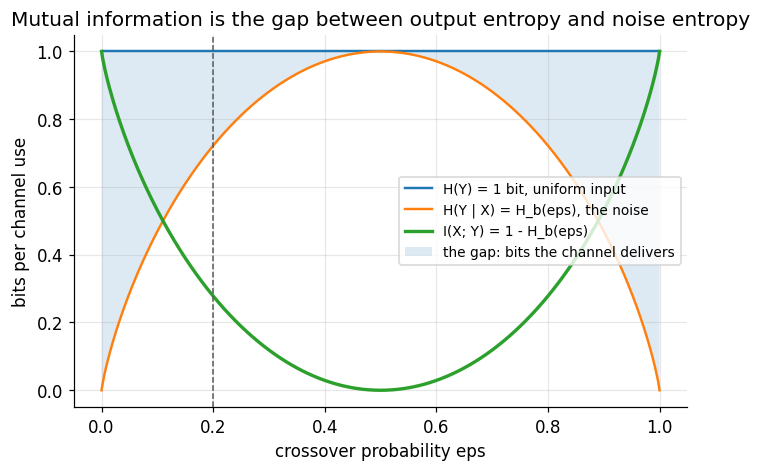

eps = 0.0:  H(Y) = 1.000000   H(Y|X) = 0.000000   I = 1.000000 bits
eps = 0.1:  H(Y) = 1.000000   H(Y|X) = 0.468996   I = 0.531004 bits
eps = 0.2:  H(Y) = 1.000000   H(Y|X) = 0.721928   I = 0.278072 bits
eps = 0.5:  H(Y) = 1.000000   H(Y|X) = 1.000000   I = 0.000000 bits


In [2]:
eps_grid = np.linspace(0.0, 1.0, 501)
H_out = np.ones_like(eps_grid)
H_out_given_in = binary_entropy(eps_grid)
I_bsc = H_out - H_out_given_in

fig, ax = plt.subplots(figsize=(7.2, 4.4))
ax.plot(eps_grid, H_out, lw=1.6, label="H(Y) = 1 bit, uniform input")
ax.plot(eps_grid, H_out_given_in, lw=1.6, label="H(Y | X) = H_b(eps), the noise")
ax.plot(eps_grid, I_bsc, lw=2.2, label="I(X; Y) = 1 - H_b(eps)")
ax.fill_between(eps_grid, H_out_given_in, H_out, alpha=0.15,
                label="the gap: bits the channel delivers")
ax.axvline(0.2, ls="--", lw=1.0, color="0.35")
ax.set_xlabel("crossover probability eps")
ax.set_ylabel("bits per channel use")
ax.set_title("Mutual information is the gap between output entropy and noise entropy")
ax.legend(fontsize=9, loc="center right")
plt.show()

for e in (0.0, 0.1, 0.2, 0.5):
    print(f"eps = {e:.1f}:  H(Y) = 1.000000   H(Y|X) = {binary_entropy(np.array(e)):.6f}"
          f"   I = {1.0 - binary_entropy(np.array(e)):.6f} bits")

At $\epsilon = 0$ the noise entropy is zero and the whole bit arrives. At $\epsilon = 0.5$ the noise
entropy fills the output entropy completely and nothing arrives.

The curve is symmetric about $\epsilon = 0.5$ because a channel that always inverts is as useful as
one that never does: relabelling the output is invertible, and Theorem 4.4 says invertible
relabelling changes nothing.

The dashed line marks $\epsilon = 0.2$, where the delivered information is $0.278072$ bits. That
number reappears in Example 6.1 as the mutual information of a joint table and in Example 6.4 as a
channel capacity, because they are the same quantity read three ways.

## 3. Definitions

Throughout, $X$ and $Y$ are jointly distributed with joint law $p(x, y)$ and marginals $p(x)$,
$p(y)$. Alphabets are $\mathcal{X}$ and $\mathcal{Y}$, of sizes $K$ and $L$ when finite.

Conventions follow [the notation register](../../docs/notation.md). Three rulings bind here:
$H(X, Y)$ is **joint** entropy and never cross-entropy; $D_{\mathrm{KL}}(p \parallel q)$ uses
`\parallel`; and every numerical answer carries its unit, **bits** for $\log_2$ and **nats** for
$\ln$. A bare $\log$ appears only where the base cancels.

### Definition 3.1 — Mutual information

For jointly distributed discrete $X, Y$,

$$
I(X; Y) = \sum_{x \in \mathcal{X}} \sum_{y \in \mathcal{Y}} p(x, y) \log \frac{p(x, y)}{p(x)\,p(y)}
= \mathbb{E}_{p(x, y)}\left[ \log \frac{p(X, Y)}{p(X)\,p(Y)} \right].
$$

The convention $0 \log \frac{0}{q} = 0$ applies, so the sum runs over the support of $p(x, y)$.

For continuous variables replace sums by integrals against densities; nothing else changes.

### Definition 3.2 — Pointwise mutual information

The quantity inside the expectation of Definition 3.1,

$$
i(x; y) = \log \frac{p(x, y)}{p(x)\,p(y)},
$$

is the **pointwise mutual information**. Unlike its average it may be negative: an outcome pair that
co-occurs less often than chance carries $i(x; y) \lt 0$.

### Definition 3.3 — Conditional mutual information

$$
I(X; Y \mid Z) = \sum_{z} p(z)\, I(X; Y \mid Z = z)
= \mathbb{E}_{p(x, y, z)}\left[ \log \frac{p(X, Y \mid Z)}{p(X \mid Z)\,p(Y \mid Z)} \right].
$$

Equivalently $I(X; Y \mid Z) = H(X \mid Z) - H(X \mid Y, Z)$: what $Y$ says about $X$ *beyond* what
$Z$ has already said.

### Definition 3.4 — Markov chain and sufficiency

Variables form a **Markov chain** $X \to Y \to Z$ when
$p(z \mid x, y) = p(z \mid y)$, equivalently when $I(X; Z \mid Y) = 0$.

A statistic $T = T(Y)$ is **sufficient** for $X$ when $X \to T \to Y$ is also a Markov chain. The
chain $X \to Y \to T$ holds automatically for any function of $Y$; sufficiency is the extra
requirement that the arrow can be reversed.

### Definition 3.5 — Discrete memoryless channel, rate, and capacity

A **discrete memoryless channel** is a conditional law $p(y \mid x)$ on finite alphabets, used $n$
times with $p(y^n \mid x^n) = \prod_{i=1}^{n} p(y_i \mid x_i)$.

Its **capacity** is the largest mutual information any input distribution can extract:

$$
C = \max_{p(x)} I(X; Y),
$$

in bits per channel use when the logarithm is base two.

A $(2^{nR}, n)$ **code** is a message set $\lbrace 1, \ldots, 2^{nR} \rbrace$, an encoder
$w \mapsto x^n(w)$, and a decoder $g : \mathcal{Y}^n \to \lbrace 1, \ldots, 2^{nR} \rbrace$. Its
average error probability is

$$
P_e^{(n)} = \frac{1}{2^{nR}} \sum_{w} \Pr\left[ g(Y^n) \neq w \mid W = w \right],
$$

and $R$ is the **rate** in bits per channel use.

### Definition 3.6 — InfoNCE loss

Draw a positive pair $(x_1, y_1) \sim p(x, y)$ and $K - 1$ independent negatives
$y_2, \ldots, y_K \sim p(y)$. A **critic** $f : \mathcal{X} \times \mathcal{Y} \to \mathbb{R}$ scores
pairs, and the **InfoNCE loss** is the $K$-way softmax cross-entropy of picking the positive:

$$
\mathcal{L}_{\mathrm{NCE}}(f) = -\,\mathbb{E}\left[ \log \frac{e^{f(x_1, y_1)}}{\sum_{j=1}^{K} e^{f(x_1, y_j)}} \right].
$$

> [!NOTE]
> The denominator carries **no** $\tfrac{1}{K}$. This is the ruling of
> [the notation register](../../docs/notation.md): under it the summand is a log-probability, so
> $\mathcal{L}_{\mathrm{NCE}} \ge 0$ pointwise, chance level is exactly $\log K$, and the bound of
> Theorem 4.8 reads $I \ge \log K - \mathcal{L}_{\mathrm{NCE}}$. With a $\tfrac{1}{K}$ inside, every
> one of those three statements shifts by $\log K$.

### Definition 3.7 — Plug-in estimator

Given $N$ paired samples over finite alphabets, let $\hat{p}(x, y)$ be the empirical frequency
table. The **plug-in** (maximum-likelihood) estimator is Definition 3.1 evaluated at $\hat{p}$:

$$
\hat{I}_{\text{plug-in}} = \sum_{x, y} \hat{p}(x, y) \log \frac{\hat{p}(x, y)}{\hat{p}(x)\,\hat{p}(y)}.
$$

It is nonnegative by construction, which is exactly why it cannot be unbiased at $I = 0$.

## 4. Main Results

Theorems 4.1 to 4.4 are the algebra of mutual information: the equivalent forms, the sign, the chain
rule, and the data-processing inequality that the whole module leans on.

Theorems 4.5 and 4.6 make capacity computable — concavity in the input, and the closed form for the
Gaussian case.

Theorems 4.7 to 4.10 are the operational half: what a bit buys you in accuracy (Fano), what a
contrastive objective can certify (InfoNCE), and where the boundary between achievable and
impossible rates sits (the coding theorem and its converse).

### Theorem 4.1 — Equivalent forms

For jointly distributed $X, Y$ with finite entropies,

$$
I(X; Y) = H(X) - H(X \mid Y) = H(Y) - H(Y \mid X) = H(X) + H(Y) - H(X, Y) = D_{\mathrm{KL}}\left( P_{XY} \parallel P_X P_Y \right).
$$

In particular $I$ is symmetric in its two arguments, and $I(X; X) = H(X)$.

**Hypotheses.** Finiteness of the entropies is the only requirement, and it is needed so that the
differences above are not $\infty - \infty$. For continuous variables the first three forms use
differential entropies and may individually depend on the choice of units; the fourth does not,
which is why Definition 3.1 is stated as a divergence.

Proved as Proof 5.1.

### Theorem 4.2 — Nonnegativity and the independence characterization

$$
I(X; Y) \ge 0, \qquad \text{with equality if and only if } p(x, y) = p(x)\,p(y) \text{ for all } (x, y).
$$

The same holds conditionally: $I(X; Y \mid Z) \ge 0$, with equality exactly when $X$ and $Y$ are
conditionally independent given $Z$.

**Hypotheses.** None beyond a well-defined joint law. The equality case needs the *strict*
concavity of the logarithm, which is what turns "the ratio is almost surely constant" into
"the ratio is one everywhere".

**Interpretation.** Combined with Theorem 4.1 this says $H(X \mid Y) \le H(X)$: side information
never hurts *on average*. It does not say a particular observation cannot hurt — Example 6.2 shows
a $Z$ whose observation raises the mutual information from $0$ to $1$ bit.

Proved as Proof 5.2.

### Theorem 4.3 — Chain rule

For any $n \ge 1$,

$$
I(X_1, \ldots, X_n; Y) = \sum_{i=1}^{n} I\left( X_i; Y \mid X_1, \ldots, X_{i-1} \right).
$$

**Hypotheses.** Only that the joint entropies are finite, so the entropy chain rule applies term by
term.

**Interpretation.** Features contribute information *in context*, never in isolation. The value of
$X_2$ is counted only after $X_1$ has been accounted for, which is why a greedy forward selection is
a chain-rule computation and why two features can each be worthless alone and jointly decisive.

Proved as Proof 5.3.

### Theorem 4.4 — Data-processing inequality

If $X \to Y \to Z$ is a Markov chain in the sense of Definition 3.4, then

$$
I(X; Y) \;\ge\; I(X; Z),
$$

and more precisely $I(X; Y) - I(X; Z) = I(X; Y \mid Z) \ge 0$.

Equality holds if and only if $X \to Z \to Y$ is also a Markov chain, that is, exactly when $Z$ is a
sufficient statistic of $Y$ for $X$.

**Corollary.** $I(X; g(Y)) \le I(X; Y)$ for every deterministic or randomized $g$, with equality
whenever $g$ is invertible.

**Hypotheses.** The Markov property is doing all the work: it is precisely the statement
$I(X; Z \mid Y) = 0$ that collapses one of the two chain-rule expansions. Section 7.3 runs a
$Z$ that is *not* a function of $Y$ and shows $I(X; Z)$ exceeding $I(X; Y)$ by a full bit.

Proved as Proof 5.4.

### Theorem 4.5 — Concavity in the input, convexity in the channel

Fix a channel $p(y \mid x)$. Then $p(x) \mapsto I(X; Y)$ is **concave**.

Fix an input $p(x)$. Then $p(y \mid x) \mapsto I(X; Y)$ is **convex**.

**Hypotheses.** Finite alphabets, so that both maps are defined on compact simplices. Concavity in
the input is what makes $C = \max_{p(x)} I(X; Y)$ a concave maximization over a simplex — a problem
with no local maxima, solvable by the Blahut-Arimoto iteration of Section 7.4.

**Interpretation.** Mixing two input distributions never loses information relative to the average
of what each achieves alone; mixing two channels never gains it. The first fact is why capacity is
computable, the second is why time-sharing between channels cannot beat using the better one.

Proved as Proof 5.5.

### Theorem 4.6 — Gaussian mutual information and the AWGN capacity

Let $(X, Y)$ be **jointly Gaussian** with correlation $\rho$, $\lvert \rho \rvert \lt 1$. Then

$$
I(X; Y) = -\tfrac{1}{2} \ln\left( 1 - \rho^{2} \right) \ \text{nats}
= -\tfrac{1}{2} \log_2\left( 1 - \rho^{2} \right) \ \text{bits}.
$$

Let $Y = X + N$ with $N \sim \mathcal{N}(0, \sigma^2)$ independent of $X$, under the second-moment
constraint $\mathbb{E}[X^2] \le P$. Then

$$
C = \max_{p(x)} I(X; Y) = \tfrac{1}{2} \ln\left( 1 + \frac{P}{\sigma^{2}} \right) \ \text{nats},
$$

attained by $X \sim \mathcal{N}(0, P)$. In bits per channel use the same quantity is
$\tfrac{1}{2} \log_2 (1 + P/\sigma^2)$; the two differ by the factor $\ln 2$ and must never be
joined by an equality sign.

**Hypotheses.** *Joint* Gaussianity, not marginal Gaussianity and not zero correlation. Section 7.3
runs an uncorrelated but strongly dependent pair for which the first formula reports $0$ bits and
the truth is $0.918296$ bits. The AWGN half rests on the maximum-entropy Lemma 5.6a, which is stated
for a **second-moment** bound $\mathbb{E}[Y^2] \le v$ — exactly what the power constraint supplies.
Under a variance bound the lemma needs an extra centring step, because a density with variance $v$
and a large mean has $\mathbb{E}[Y^2] \gg v$ and the displayed inequality fails.

Proved as Proof 5.6.

### Theorem 4.7 — Fano's inequality

Let $X$ take values in an alphabet of size $K$, let $X \to Y \to \hat{X}$ with $\hat{X} = g(Y)$, and
let $P_e = \Pr[\hat{X} \neq X]$. Then

$$
H(X \mid Y) \;\le\; H_b(P_e) + P_e \log (K - 1).
$$

The canonical statement and proof for this repository live in
[Module 02, Proof 3.6](../02_joint_and_conditional_entropy/first_principles.ipynb); the alphabet
symbol $K$ is the register's.

**Corollary 4.7a (accuracy ceiling).** Since $H_b \le \log 2$ and $\log(K-1) \le \log K$,

$$
P_e \;\ge\; \frac{H(X) - I(X; Y) - \log 2}{\log K}.
$$

**Hypotheses.** The Markov chain $X \to Y \to \hat{X}$ is what lets $H(X \mid Y) \le H(X \mid \hat{X})$
be applied; without it the estimator could consult $X$ directly. Note that $H_b(P_e)$ is symmetric
about $\tfrac{1}{2}$, so solving the inequality for $P_e$ yields an interval, and the useful root is
the smaller one.

**Interpretation.** Accuracy is capped by information. A classifier whose features carry
$I(X; Y)$ bits about a label of entropy $H(X)$ cannot beat the ceiling, whatever its architecture.

The corollary is often vacuous, and Example 6.6 shows a case where it returns $P_e \ge 0$ while the
unweakened inequality returns $P_e \ge 0.189290$. Proof 5.7 derives the corollary and shows where
the slack enters.

### Theorem 4.8 — The InfoNCE bound and its $\log K$ ceiling

Let $\mathcal{L}_{\mathrm{NCE}}(f)$ be as in Definition 3.6, with **no** $\tfrac{1}{K}$ in the
denominator. Then for every critic $f$ and every $K \ge 1$,

$$
I(X; Y) \;\ge\; \log K - \mathcal{L}_{\mathrm{NCE}}(f),
$$

and because $\mathcal{L}_{\mathrm{NCE}}(f) \ge 0$ pointwise, the bound can never certify more than

$$
\log K \ \text{nats}.
$$

The loss is minimized, and the bound therefore tightest, at
$f^{\star}(x, y) = \log \frac{p(y \mid x)}{p(y)} + c(x)$ for any function $c$.

**Hypotheses.** The negatives must be drawn from the *marginal* $p(y)$, independently of $x_1$; that
independence is what makes the normalizer's expectation equal one in Proof 5.8. Section 7.3 draws
negatives from a law that depends on $x_1$ and watches the bound fail by $0.154044$ nats. Nothing is
assumed about $f$: it may be any measurable function, and the bound holds for a badly trained critic
exactly as it does for the optimal one.

**Interpretation.** A batch of $K = 256$ can certify at most $\log 256 = 5.545$ nats, that is
$8$ bits, however large the truth. Contrastive objectives are excellent *training signals* and poor
*measurements*, and the whole engineering programme of large batches, memory banks and momentum
encoders is a fight against this one inequality.

Proved as Proof 5.8.

### Theorem 4.9 (cited, not proved here) — Achievability half of the noisy-channel coding theorem

For a discrete memoryless channel of capacity $C$ and every rate $R \lt C$, there exists a sequence
of $(2^{nR}, n)$ codes with $P_e^{(n)} \to 0$ as $n \to \infty$.

The proof is Shannon's random-coding argument with joint-typicality decoding. It is out of scope
here because it needs the asymptotic equipartition property and the joint-typicality lemma, neither
of which this module develops.

**Reference.** Cover, T. M. and Thomas, J. A., *Elements of Information Theory*, 2nd ed., section
7.7, Theorem 7.7.1, pages 199-205 (achievability at pages 200-204).

What the module *can* prove in full is the converse, which is the half that makes $C$ a hard
ceiling rather than a lower bound on what is possible.

### Theorem 4.10 — Converse to the coding theorem

Let a sequence of $(2^{nR}, n)$ codes over a discrete memoryless channel of capacity $C$ satisfy
$P_e^{(n)} \to 0$, with the message $W$ uniform on $\lbrace 1, \ldots, 2^{nR} \rbrace$. Then

$$
R \le C .
$$

Non-asymptotically, for every $n$,

$$
P_e^{(n)} \;\ge\; 1 - \frac{C}{R} - \frac{1}{nR}.
$$

**Hypotheses.** Memorylessness supplies the single-letter bound $I(X^n; Y^n) \le nC$ of Lemma 5.9a;
Section 7.3 runs a two-use channel whose noise bit is shared between the uses and measures
$I(X^2; Y^2) = 1.531004$ bits against $2C = 1.062009$. Uniformity of $W$ supplies $H(W) = nR$, and
$\hat{W} = g(Y^n)$ supplies the Markov chain $W \to X^n \to Y^n \to \hat{W}$ that Fano needs.

**Interpretation.** Above capacity the error probability is bounded away from zero by an amount that
does not shrink with the block length. Longer codes do not help; only a lower rate does.

Proved as Proof 5.9.

### Proposition 4.11 (cited, not proved here) — Bias of the plug-in estimator

For fixed alphabets of sizes $K$ and $L$ and $N$ independent paired samples, the plug-in estimator
of Definition 3.7 satisfies

$$
\mathbb{E}\left[ \hat{I}_{\text{plug-in}} \right] = I(X; Y) + \frac{(K - 1)(L - 1)}{2N} + O\!\left( N^{-2} \right) \ \text{nats}.
$$

The bias is **positive** and grows with the number of table cells, so independent variables never
estimate to zero.

**Reference.** Paninski, L. "Estimation of entropy and mutual information", *Neural Computation*
**15**(6), 2003, 1191-1253, section 4 (the Miller-Madow expansion is equation 12, page 1201).

Section 7.2 measures the exponent and the constant rather than assuming them.

## 5. Derivations and Proofs

### Proof 5.1 (of Theorem 4.1, the equivalent forms)

**Step 1 — split the logarithm.** Write $p(x, y) = p(x \mid y)\,p(y)$ inside Definition 3.1, so that
the factor $p(y)$ cancels:

$$
I(X; Y) = \sum_{x, y} p(x, y) \log \frac{p(x \mid y)}{p(x)}
= \sum_{x, y} p(x, y) \log \frac{1}{p(x)} - \sum_{x, y} p(x, y) \log \frac{1}{p(x \mid y)} .
$$

**Step 2 — recognize the two entropies.** The first sum marginalizes $y$ away and is $H(X)$; the
second is the definition of $H(X \mid Y)$. Hence

$$
I(X; Y) = H(X) - H(X \mid Y) .
$$

**Step 3 — symmetry.** The ratio $\frac{p(x, y)}{p(x) p(y)}$ is unchanged when $x$ and $y$ swap
roles, so Definition 3.1 is symmetric, and repeating Steps 1 and 2 with the roles exchanged gives

$$
I(X; Y) = H(Y) - H(Y \mid X) .
$$

**Step 4 — the union form.** Substitute the entropy chain rule $H(X \mid Y) = H(X, Y) - H(Y)$ into
Step 2:

$$
I(X; Y) = H(X) + H(Y) - H(X, Y) .
$$

**Step 5 — the divergence form.** Definition 3.1 is literally
$\sum_{x,y} p(x,y) \log \frac{p(x,y)}{q(x,y)}$ with $q = p(x)p(y)$, which is the definition of
$D_{\mathrm{KL}}(P_{XY} \parallel P_X P_Y)$.

$$
\boxed{I(X; Y) = H(X) - H(X \mid Y) = H(Y) - H(Y \mid X) = H(X) + H(Y) - H(X, Y) = D_{\mathrm{KL}}\left( P_{XY} \parallel P_X P_Y \right)}
$$

**Interpretation.** Four different measurements — bits saved when describing $X$, bits saved when
describing $Y$, the overlap of two entropy areas, and the distance from the joint law to the
independent one — return the same number. That coincidence is what makes mutual information the
canonical measure of dependence rather than one candidate among many.

Setting $Y = X$ gives $H(X \mid X) = 0$ and hence $I(X; X) = H(X)$: entropy is self-information in
the literal sense. $\blacksquare$

### Proof 5.2 (of Theorem 4.2, nonnegativity and the equality case)

Work in nats; changing the base multiplies everything by a positive constant and changes nothing.

**Lemma 5.2a — the tangent-line bound.** For every $t \gt 0$,

$$
\ln t \le t - 1,
$$

with equality only at $t = 1$.

*Proof of the lemma.* Put $\varphi(t) = t - 1 - \ln t$ on $(0, \infty)$. Then
$\varphi'(t) = 1 - 1/t$, which vanishes only at $t = 1$, and $\varphi''(t) = 1/t^{2} \gt 0$, so
$\varphi$ is strictly convex with a unique global minimum at $t = 1$, where $\varphi(1) = 0$. Hence
$\varphi \ge 0$ with equality only at $t = 1$.

This three-line lemma is all that is needed; it is the special case $f(t) = t \ln t$ of the
$f$-divergence machinery of
[Module 04](../04_kl_divergence_and_f_divergences/first_principles.ipynb), which generalizes it, and
nothing here depends on that module.

**Step 1 — apply the lemma pointwise.** Let $S = \lbrace (x, y) : p(x, y) \gt 0 \rbrace$ and apply
Lemma 5.2a to $t = \frac{p(x)p(y)}{p(x,y)}$ at each point of $S$:

$$
-I(X; Y) = \sum_{(x,y) \in S} p(x, y) \ln \frac{p(x)p(y)}{p(x, y)}
\le \sum_{(x,y) \in S} p(x, y) \left( \frac{p(x)p(y)}{p(x, y)} - 1 \right).
$$

**Step 2 — evaluate the right-hand side.** The factors $p(x,y)$ cancel in the first term:

$$
\sum_{(x,y) \in S} p(x, y) \left( \frac{p(x)p(y)}{p(x, y)} - 1 \right)
= \sum_{(x,y) \in S} p(x)p(y) \;-\; 1 \;\le\; 1 - 1 = 0,
$$

because $S$ is a subset of $\mathcal{X} \times \mathcal{Y}$ and the product measure of the whole
space is $1$.

**Step 3 — conclude.** Combining the two displays, $-I(X; Y) \le 0$, that is $I(X; Y) \ge 0$.

**Step 4 — the equality case.** Equality in Step 1 forces $\frac{p(x)p(y)}{p(x,y)} = 1$ at every
point of $S$, by the strict part of Lemma 5.2a. Equality in Step 2 forces
$\sum_{S} p(x)p(y) = 1$, so the product measure puts no mass outside $S$. Together:
$p(x, y) = p(x)p(y)$ everywhere, which is independence. Conversely independence makes every
logarithm zero.

**Step 5 — the conditional statement.** Definition 3.3 writes $I(X; Y \mid Z)$ as an average of
quantities $I(X; Y \mid Z = z)$, each of which is an unconditional mutual information for the
conditional law $p(\cdot, \cdot \mid z)$. Steps 1 to 4 apply to each, and a nonnegative average of
nonnegative terms is nonnegative, with equality exactly when every term vanishes.

$$
\boxed{I(X; Y) \ge 0, \qquad I(X; Y) = 0 \iff X \perp Y; \qquad I(X; Y \mid Z) \ge 0}
$$

**Interpretation.** Read through Theorem 4.1 this is the statement $H(X \mid Y) \le H(X)$:
side information never increases average uncertainty. The word *average* is load-bearing —
a particular observed value $Y = y$ can leave $X$ more uncertain than before, and Example 6.2
constructs a $Z$ for which conditioning raises the mutual information from zero to one bit.
$\blacksquare$

### Proof 5.3 (of Theorem 4.3, the chain rule)

**Step 1 — the two-variable case, from the entropy form.** By Theorem 4.1,

$$
I(X_1, X_2; Y) = H(X_1, X_2) - H(X_1, X_2 \mid Y) .
$$

**Step 2 — expand both terms with the entropy chain rule.**

$$
H(X_1, X_2) = H(X_1) + H(X_2 \mid X_1), \qquad
H(X_1, X_2 \mid Y) = H(X_1 \mid Y) + H(X_2 \mid X_1, Y) .
$$

**Step 3 — regroup the four pieces in pairs.**

$$
I(X_1, X_2; Y) = \underbrace{\left[ H(X_1) - H(X_1 \mid Y) \right]}_{I(X_1; Y)}
+ \underbrace{\left[ H(X_2 \mid X_1) - H(X_2 \mid X_1, Y) \right]}_{I(X_2; Y \mid X_1)} .
$$

**Step 4 — induct.** Treat $(X_1, \ldots, X_{n-1})$ as a single variable and apply Step 3; the
inductive hypothesis expands the first term.

$$
\boxed{I(X_1, \ldots, X_n; Y) = \sum_{i=1}^{n} I\left( X_i; Y \mid X_1, \ldots, X_{i-1} \right)}
$$

**Interpretation.** The decomposition is sequential and order-dependent in its individual terms
while its total is not. Every term after the first is *conditional*, which is why summing marginal
relevances $I(X_i; Y)$ is not a valid feature score: Example 6.2 exhibits two features with
$I(X_i; Y) = 0$ each and $I(X_1, X_2; Y) = 1$ bit together. $\blacksquare$

### Proof 5.4 (of Theorem 4.4, the data-processing inequality)

**Step 1 — expand $I(X; Y, Z)$ in both orders.** Theorem 4.3 with $n = 2$, applied twice:

$$
I(X; Y, Z) = I(X; Y) + I(X; Z \mid Y) = I(X; Z) + I(X; Y \mid Z) .
$$

**Step 2 — use the Markov hypothesis.** By Definition 3.4, $X \to Y \to Z$ says exactly
$I(X; Z \mid Y) = 0$, so the first expansion collapses:

$$
I(X; Y, Z) = I(X; Y) .
$$

**Step 3 — subtract.** Substituting Step 2 into the second expansion of Step 1,

$$
I(X; Y) - I(X; Z) = I(X; Y \mid Z) \;\ge\; 0
$$

by Theorem 4.2, which is the claim.

**Step 4 — the equality case.** Equality holds precisely when $I(X; Y \mid Z) = 0$, which by
Theorem 4.2 is conditional independence of $X$ and $Y$ given $Z$, that is, the Markov chain
$X \to Z \to Y$. By Definition 3.4 that is exactly sufficiency of $Z$.

**Step 5 — the corollary for functions.** For any $g$, possibly randomized, the variable $g(Y)$
depends on $X$ only through $Y$, so $X \to Y \to g(Y)$ and $I(X; g(Y)) \le I(X; Y)$. If $g$ is
invertible then $Y = g^{-1}(g(Y))$ is also a function of $g(Y)$, so the reverse chain
$X \to g(Y) \to Y$ holds and the inequality runs both ways.

$$
\boxed{X \to Y \to Z \implies I(X; Y) - I(X; Z) = I(X; Y \mid Z) \ge 0, \quad \text{equality} \iff Z \text{ sufficient}}
$$

**Interpretation.** Processing cannot create information, and the exact amount destroyed is
$I(X; Y \mid Z)$ — the part of $Y$'s testimony that $Z$ fails to relay. In a feedforward network
$X \to Z_1 \to Z_2 \to \cdots$, the information about the input is non-increasing with depth, so any
measured increase is an estimation artefact rather than a discovery. $\blacksquare$

### Proof 5.5 (of Theorem 4.5, concavity in the input and convexity in the channel)

**Part 1 — concavity in $p(x)$ for a fixed channel.**

*Step 1.* Write $I(X; Y) = H(Y) - H(Y \mid X)$ from Theorem 4.1.

*Step 2 — the second term is linear.* By definition
$H(Y \mid X) = \sum_x p(x)\, H\left( p(\cdot \mid x) \right)$, and the channel is fixed, so each
$H(p(\cdot \mid x))$ is a constant. The map $p(x) \mapsto H(Y \mid X)$ is therefore linear.

*Step 3 — the first term is concave.* The output law $p(y) = \sum_x p(x)\, p(y \mid x)$ is linear in
$p(x)$. The entropy $H(q) = \sum_y \eta(q(y))$ with $\eta(t) = -t \log t$ is a sum of concave
functions of the coordinates, hence concave in $q$. A concave function composed with a linear map is
concave, so $p(x) \mapsto H(Y)$ is concave.

*Step 4.* Concave minus linear is concave.

**Part 2 — convexity in $p(y \mid x)$ for a fixed input.**

*Lemma 5.5a — the log-sum inequality.* For nonnegative $a_1, \ldots, a_m$ and positive
$b_1, \ldots, b_m$,

$$
\sum_{i} a_i \log \frac{a_i}{b_i} \;\ge\; \left( \sum_i a_i \right) \log \frac{\sum_i a_i}{\sum_i b_i} .
$$

*Proof of the lemma.* The function $\eta(t) = t \log t$ is convex. Put $B = \sum_i b_i$ and apply
Jensen with weights $b_i / B$ to the points $t_i = a_i / b_i$:

$$
\sum_i \frac{b_i}{B} \, \eta\!\left( \frac{a_i}{b_i} \right) \;\ge\; \eta\!\left( \sum_i \frac{b_i}{B} \cdot \frac{a_i}{b_i} \right) = \eta\!\left( \frac{\sum_i a_i}{B} \right).
$$

Multiplying by $B$ gives the claim.

*Step 1 — joint convexity of the divergence.* Let $\lambda \in [0, 1]$. Applying Lemma 5.5a at each
$x$ with $a_1 = \lambda p_1(x)$, $a_2 = (1-\lambda) p_2(x)$, $b_1 = \lambda q_1(x)$,
$b_2 = (1-\lambda) q_2(x)$ and summing over $x$,

$$
D_{\mathrm{KL}}\left( \lambda p_1 + (1-\lambda) p_2 \parallel \lambda q_1 + (1-\lambda) q_2 \right)
\;\le\; \lambda D_{\mathrm{KL}}(p_1 \parallel q_1) + (1-\lambda) D_{\mathrm{KL}}(p_2 \parallel q_2).
$$

*Step 2 — write $I$ as an average of divergences.* For a fixed input,

$$
I(X; Y) = \sum_x p(x) \, D_{\mathrm{KL}}\left( p(\cdot \mid x) \parallel p_Y \right),
\qquad p_Y(y) = \sum_x p(x) p(y \mid x).
$$

*Step 3 — mix two channels.* Let $W = \lambda W_1 + (1-\lambda) W_2$. Because $p(x)$ is fixed, the
induced output law mixes the same way: $p_Y^{W} = \lambda p_Y^{W_1} + (1-\lambda) p_Y^{W_2}$.
Applying Step 1 at each $x$ to the pair $\left( W(\cdot \mid x), p_Y^{W} \right)$ and averaging with
weights $p(x)$ gives $I^{W} \le \lambda I^{W_1} + (1-\lambda) I^{W_2}$.

$$
\boxed{p(x) \mapsto I(X; Y) \text{ is concave}; \qquad p(y \mid x) \mapsto I(X; Y) \text{ is convex}}
$$

**Interpretation.** Concavity in the input is the reason capacity is computable at all: maximizing a
concave function over the probability simplex has no local maxima, so the alternating Blahut-Arimoto
iteration of Section 7.4 cannot get stuck. Convexity in the channel says that a channel drawn at
random from two options carries at most the average of what the two carry, so randomizing hardware
never helps. $\blacksquare$

### Proof 5.6 (of Theorem 4.6, the Gaussian case)

**Part 1 — the bivariate Gaussian.**

*Step 1 — reduce to unit variances.* Scaling $X$ and $Y$ by nonzero constants is invertible, so by
Step 5 of Proof 5.4 it leaves $I$ unchanged. Assume $\operatorname{Var}(X) = \operatorname{Var}(Y) = 1$, so that
$\Sigma = \begin{pmatrix} 1 & \rho \\ \rho & 1 \end{pmatrix}$ and $\det \Sigma = 1 - \rho^2$.

*Step 2 — the two differential entropies.* For a $d$-dimensional Gaussian with covariance $\Sigma$,
$h = \tfrac{1}{2}\ln\left( (2\pi e)^{d} \det \Sigma \right)$. Hence

$$
h(X) = h(Y) = \tfrac{1}{2}\ln(2 \pi e), \qquad h(X, Y) = \tfrac{1}{2}\ln\left( (2\pi e)^2 (1 - \rho^2) \right).
$$

*Step 3 — the union form.* The algebra of Proof 5.1 Step 4 never used discreteness, only finiteness,
so it holds verbatim for differential entropies:

$$
I(X; Y) = h(X) + h(Y) - h(X, Y) = -\tfrac{1}{2}\ln\left( 1 - \rho^2 \right) \ \text{nats}.
$$

The unit-dependent constant $\tfrac{1}{2}\ln(2\pi e)$ appears twice with a plus sign and twice with a
minus sign, and cancels. That cancellation is why $I$ survives the passage to densities while $h$
alone does not.

**Part 2 — the additive white Gaussian noise channel.**

*Step 1 — remove the input from the conditional entropy.* Given $X = x$, the output $Y = x + N$ is
the noise translated by a constant, and differential entropy is translation invariant, so
$h(Y \mid X) = h(N) = \tfrac{1}{2}\ln(2\pi e \sigma^2)$ and

$$
I(X; Y) = h(Y) - h(N).
$$

Only $h(Y)$ is under our control.

*Lemma 5.6a — maximum entropy under a second-moment constraint.* Among densities $p$ on
$\mathbb{R}$ with $\mathbb{E}_p[Y^2] \le v$, the centred Gaussian $\phi_v$ maximizes differential
entropy, and $h(\phi_v) = \tfrac{1}{2}\ln(2\pi e v)$.

*Proof of the lemma.* Nonnegativity of the divergence gives

$$
0 \le D_{\mathrm{KL}}(p \parallel \phi_v) = -h(p) - \int p(y) \ln \phi_v(y)\, dy .
$$

Since $\ln \phi_v(y) = -\tfrac{1}{2}\ln(2\pi v) - \frac{y^2}{2v}$ is a quadratic, the integral sees
$p$ only through its **second moment**:

$$
-\int p \ln \phi_v = \tfrac{1}{2}\ln(2\pi v) + \frac{\mathbb{E}_p[Y^2]}{2v}
\;\le\; \tfrac{1}{2}\ln(2\pi v) + \tfrac{1}{2} = h(\phi_v),
$$

where the inequality is exactly the hypothesis $\mathbb{E}_p[Y^2] \le v$. Combining,
$h(p) \le h(\phi_v)$, with equality iff $p = \phi_v$.

The constraint must be on the second moment, not the variance: a density with variance $v$ and a
large mean has $\mathbb{E}[Y^2] \gg v$ and the last inequality fails. A variance constraint suffices
only when $\mathbb{E}[Y] = 0$ is also imposed, and shifting to zero mean changes neither $h$ nor $I$.

*Step 2 — apply the lemma.* Independence of $X$ and $N$ with $\mathbb{E}[N] = 0$ gives
$\mathbb{E}[Y^2] = \mathbb{E}[X^2] + \sigma^2 \le P + \sigma^2$, which is a second-moment bound of
exactly the form Lemma 5.6a requires. Hence

$$
h(Y) \le \tfrac{1}{2}\ln\left( 2\pi e (P + \sigma^2) \right).
$$

*Step 3 — subtract and check achievability.*

$$
I(X; Y) \le \tfrac{1}{2}\ln\left( 2\pi e (P + \sigma^2) \right) - \tfrac{1}{2}\ln\left( 2\pi e \sigma^2 \right)
= \tfrac{1}{2}\ln\left( 1 + \frac{P}{\sigma^2} \right) \ \text{nats},
$$

and $X \sim \mathcal{N}(0, P)$ makes $Y \sim \mathcal{N}(0, P + \sigma^2)$, attaining it.

$$
\boxed{I_{\text{Gauss}} = -\tfrac{1}{2}\ln\left(1 - \rho^{2}\right) \ \text{nats}, \qquad C_{\mathrm{AWGN}} = \tfrac{1}{2}\ln\left(1 + \frac{P}{\sigma^{2}}\right) \ \text{nats}}
$$

In bits per channel use the same two quantities are $-\tfrac{1}{2}\log_2(1 - \rho^2)$ and
$\tfrac{1}{2}\log_2(1 + P/\sigma^2)$. The nat and bit values differ by the factor $\ln 2$ and are
never equal.

**Interpretation.** Capacity grows only logarithmically in the signal-to-noise ratio, so doubling
the rate costs squaring the power ratio — the reason communication engineering buys bandwidth rather
than power, and the reason $\rho = 0.9 \to 0.99$ buys only about $1.6$ extra bits for a tenfold
increase in SNR. $\blacksquare$

### Proof 5.7 (of Corollary 4.7a, the accuracy ceiling)

Take Theorem 4.7 as given; its proof is
[Module 02, Proof 3.6](../02_joint_and_conditional_entropy/first_principles.ipynb).

**Step 1 — weaken the two right-hand terms.** The binary entropy of any probability is at most
$\log 2$, and $\log(K - 1) \le \log K$, so

$$
H(X \mid Y) \le H_b(P_e) + P_e \log (K - 1) \le \log 2 + P_e \log K .
$$

**Step 2 — rewrite the left-hand side.** By Theorem 4.1, $H(X \mid Y) = H(X) - I(X; Y)$.

**Step 3 — solve for $P_e$.**

$$
H(X) - I(X; Y) \le \log 2 + P_e \log K
\quad \Longrightarrow \quad
P_e \ge \frac{H(X) - I(X; Y) - \log 2}{\log K}.
$$

$$
\boxed{P_e \;\ge\; \frac{H(X) - I(X; Y) - \log 2}{\log K}}
$$

**Interpretation and where the slack is.** Both weakenings in Step 1 are wasteful. Replacing
$H_b(P_e)$ by $\log 2$ costs everything when $P_e$ is small, and replacing $\log(K-1)$ by $\log K$
costs a lot when $K$ is small. Example 6.6 runs a case where this corollary returns the vacuous
$P_e \ge 0$ while solving the unweakened inequality of Theorem 4.7 numerically returns
$P_e \ge 0.189290$. Use the corollary for asymptotics and the root of the full inequality for
numbers. $\blacksquare$

### Proof 5.8 (of Theorem 4.8, the InfoNCE bound)

Work in nats.

**Lemma 5.8a — the unnormalized variational form of the divergence.** Let $P \ll Q$ and let $h$ be
measurable with $\mathbb{E}_Q\left[ e^{h-1} \right] \lt \infty$. Then

$$
D_{\mathrm{KL}}(P \parallel Q) \;\ge\; \mathbb{E}_P[h] - \mathbb{E}_Q\left[ e^{h - 1} \right],
$$

with equality if and only if $h = 1 + \ln \frac{dP}{dQ}$.

*Proof of the lemma.* Write $t = \frac{dP}{dQ}$, so that $\mathbb{E}_P[h] = \mathbb{E}_Q[t h]$ and

$$
\mathbb{E}_P[h] - \mathbb{E}_Q\left[ e^{h-1} \right] = \mathbb{E}_Q\left[ t h - e^{h-1} \right].
$$

For each fixed $t \ge 0$ the map $h \mapsto t h - e^{h-1}$ is concave with derivative
$t - e^{h-1}$, so it is maximized at $h = 1 + \ln t$, where its value is $t \ln t$. Therefore the
integrand is bounded above pointwise by $t \ln t$, and

$$
\mathbb{E}_Q\left[ t h - e^{h-1} \right] \le \mathbb{E}_Q\left[ t \ln t \right] = D_{\mathrm{KL}}(P \parallel Q).
$$

**Step 1 — build the two measures.** On the augmented space of tuples $(x, y_1, \ldots, y_K)$ put

$$
P = p(x, y_1) \prod_{j=2}^{K} p(y_j), \qquad Q = p(x) \prod_{j=1}^{K} p(y_j).
$$

$P$ is the law of one positive pair together with $K-1$ independent negatives, which is exactly the
sampling scheme of Definition 3.6. Their density ratio involves only the first coordinate pair:

$$
\frac{dP}{dQ}(x, y_{1:K}) = \frac{p(x, y_1)}{p(x)\, p(y_1)},
\qquad \text{so} \qquad
D_{\mathrm{KL}}(P \parallel Q) = I(X; Y).
$$

**Step 2 — choose the test function.** With $m(x; y_{1:K}) = \frac{1}{K}\sum_{j=1}^{K} e^{f(x, y_j)}$,
take

$$
h(x, y_{1:K}) = 1 + \ln \frac{e^{f(x, y_1)}}{m(x; y_{1:K})}.
$$

**Step 3 — the left term is the InfoNCE objective.** Since
$\frac{e^{f_1}}{m} = \frac{K e^{f_1}}{\sum_j e^{f_j}}$,

$$
\mathbb{E}_P[h] = 1 + \ln K + \mathbb{E}_P\left[ \ln \frac{e^{f(x, y_1)}}{\sum_{j} e^{f(x, y_j)}} \right]
= 1 + \ln K - \mathcal{L}_{\mathrm{NCE}}(f).
$$

**Step 4 — the right term is exactly one.** Under $Q$ the variables $y_1, \ldots, y_K$ are
independent and identically distributed and independent of $x$, so the $K$ random variables
$e^{f(x, y_j)}/m$ are exchangeable and share a common mean. Their sum is deterministic:

$$
\sum_{j=1}^{K} \frac{e^{f(x, y_j)}}{m(x; y_{1:K})} = \frac{\sum_j e^{f(x,y_j)}}{\frac{1}{K}\sum_j e^{f(x,y_j)}} = K .
$$

Taking expectations, $K \, \mathbb{E}_Q\left[ e^{f(x,y_1)}/m \right] = K$, so
$\mathbb{E}_Q\left[ e^{h-1} \right] = \mathbb{E}_Q\left[ e^{f(x,y_1)}/m \right] = 1$.

This step is where the hypothesis "negatives drawn from the marginal, independently of $x_1$" is
consumed. Without exchangeability the $K$ means differ and the normalizer is not one.

**Step 5 — assemble.** Lemma 5.8a with Steps 1, 3 and 4:

$$
I(X; Y) \;\ge\; \left( 1 + \ln K - \mathcal{L}_{\mathrm{NCE}}(f) \right) - 1 = \ln K - \mathcal{L}_{\mathrm{NCE}}(f).
$$

**Step 6 — the ceiling.** The softmax probability $\frac{e^{f_1}}{\sum_j e^{f_j}}$ lies in $(0, 1]$,
so its negative logarithm is nonnegative *pointwise*, hence $\mathcal{L}_{\mathrm{NCE}}(f) \ge 0$ and

$$
\ln K - \mathcal{L}_{\mathrm{NCE}}(f) \le \ln K .
$$

**Step 7 — the best critic and the size of the gap.** $\mathcal{L}_{\mathrm{NCE}}$ is the
cross-entropy of the softmax against the true posterior over which index is the positive, and that
posterior is

$$
\Pr\left[ j \text{ is the positive} \mid x_1, y_{1:K} \right] = \frac{r(x_1, y_j)}{\sum_{k} r(x_1, y_k)},
\qquad r(x, y) = \frac{p(y \mid x)}{p(y)} .
$$

Cross-entropy is minimized by the true posterior, so any
$f^{\star} = \ln r + c(x)$ attains the minimum, and the additive $c(x)$ cancels in the softmax. At
$f^{\star}$ the residual gap is

$$
I(X; Y) - \left( \ln K - \mathcal{L}_{\mathrm{NCE}}(f^{\star}) \right)
= \mathbb{E}_P\left[ \ln \left( \tfrac{1}{K} \textstyle\sum_{j} r(x_1, y_j) \right) \right].
$$

As $K$ grows the average inside converges to $\mathbb{E}_{y \sim p(y)}[r] = 1$ and the gap closes;
for small $K$ the positive term $r(x_1,y_1)/K$ dominates the average and the bound saturates near
$\ln K$. Section 7.5 measures both regimes.

$$
\boxed{I(X; Y) \ge \log K - \mathcal{L}_{\mathrm{NCE}}(f) \quad \text{for every } f, \qquad \text{and the bound never exceeds } \log K}
$$

**Interpretation.** The certificate a contrastive run hands you is $\log K - \mathcal{L}$, and it is
a floor, never a measurement. Reporting "our representation has $15$ bits of mutual information"
from a batch of $65536$ is a category error: the correct sentence is "at least $15.28$ bits, as
certified by this estimator at this batch size". $\blacksquare$

### Proof 5.9 (of Theorem 4.10, the converse)

Work in bits, so that a rate $R$ and the message entropy $nR$ share units.

**Lemma 5.9a — the single-letter bound.** For a discrete memoryless channel and any joint law on
$X^n$,

$$
I(X^n; Y^n) \;\le\; \sum_{i=1}^{n} I(X_i; Y_i) \;\le\; n C .
$$

*Proof of the lemma.* Memorylessness gives
$p(y^n \mid x^n) = \prod_i p(y_i \mid x_i)$, so the outputs are conditionally independent given the
inputs and each depends on its own input only:

$$
H(Y^n \mid X^n) = \sum_{i=1}^{n} H(Y_i \mid X_i).
$$

Subadditivity of entropy — the chain rule $H(Y^n) = \sum_i H(Y_i \mid Y^{i-1})$ followed by
$H(Y_i \mid Y^{i-1}) \le H(Y_i)$, which is Theorem 4.2 — gives
$H(Y^n) \le \sum_i H(Y_i)$. Subtracting,

$$
I(X^n; Y^n) = H(Y^n) - H(Y^n \mid X^n) \le \sum_i \left[ H(Y_i) - H(Y_i \mid X_i) \right] = \sum_i I(X_i; Y_i),
$$

and each term is at most $C$ by Definition 3.5.

**Step 1 — set up.** Let $W$ be uniform on $\lbrace 1, \ldots, 2^{nR} \rbrace$, so $H(W) = nR$ bits.
The code defines the Markov chain

$$
W \to X^n(W) \to Y^n \to \hat{W} = g(Y^n).
$$

**Step 2 — split the message entropy.** By Theorem 4.1,

$$
nR = H(W) = I(W; Y^n) + H(W \mid Y^n).
$$

**Step 3 — bound the information term.** $W \to X^n \to Y^n$ is a Markov chain, so Theorem 4.4 and
Lemma 5.9a give

$$
I(W; Y^n) \le I(X^n; Y^n) \le n C .
$$

**Step 4 — bound the residual entropy with Fano.** $W \to Y^n \to \hat{W}$ is a Markov chain, so
Theorem 4.4 gives $I(W; Y^n) \ge I(W; \hat{W})$ and hence $H(W \mid Y^n) \le H(W \mid \hat{W})$.
Theorem 4.7 applied with alphabet size $2^{nR}$ then yields

$$
H(W \mid Y^n) \le H_b\!\left( P_e^{(n)} \right) + P_e^{(n)} \log_2\left( 2^{nR} - 1 \right) \le 1 + P_e^{(n)} \, n R .
$$

**Step 5 — combine.** Substituting Steps 3 and 4 into Step 2,

$$
nR \le nC + 1 + P_e^{(n)} \, nR .
$$

**Step 6 — divide by $nR$ and rearrange.**

$$
1 \le \frac{C}{R} + \frac{1}{nR} + P_e^{(n)}
\qquad \Longrightarrow \qquad
P_e^{(n)} \ge 1 - \frac{C}{R} - \frac{1}{nR}.
$$

**Step 7 — take the limit.** If $P_e^{(n)} \to 0$ then letting $n \to \infty$ leaves
$0 \ge 1 - C/R$, that is $R \le C$.

$$
\boxed{P_e^{(n)} \ge 1 - \frac{C}{R} - \frac{1}{nR}; \qquad P_e^{(n)} \to 0 \implies R \le C}
$$

**Interpretation.** Above capacity the error floor is a positive constant that longer blocks do not
reduce — Step 6 shows the only $n$-dependent term shrinking to zero, leaving $1 - C/R$ standing.
Together with Theorem 4.9 this makes $C$ a sharp threshold, and it is the reason capacity is quoted
as a physical limit rather than as the performance of a particular code. $\blacksquare$

## 6. Worked Examples

Every example below is small enough to finish by hand, and each main result of Section 4 gets one.
Three code cells then recompute the same numbers and assert agreement.

### Example 6.1 — A symmetric binary joint, three ways (Theorems 4.1 and 4.2)

Take the joint table

$$
p(x, y) = \begin{pmatrix} 0.4 & 0.1 \\ 0.1 & 0.4 \end{pmatrix},
$$

rows indexed by $x \in \lbrace 0, 1 \rbrace$ and columns by $y \in \lbrace 0, 1 \rbrace$.

*Marginals.* Both rows and both columns sum to $0.5$, so $X$ and $Y$ are fair bits and
$H(X) = H(Y) = 1$ bit.

*Joint entropy.*

$$
H(X, Y) = -2\left( 0.4 \log_2 0.4 \right) - 2 \left( 0.1 \log_2 0.1 \right)
= 0.8 \times 1.321928 + 0.2 \times 3.321928 = 1.721928 \ \text{bits}.
$$

*Union form.* $I = 1 + 1 - 1.721928 = 0.278072$ bits.

*Entropy form.* Given $Y = 0$, which has probability $0.5$, the conditional law of $X$ is
$(0.8, 0.2)$; by symmetry the same holds at $Y = 1$. So $H(X \mid Y) = H_b(0.2) = 0.721928$ and
$I = 1 - 0.721928 = 0.278072$ bits.

*Divergence form.* On the diagonal the ratio is $0.4 / 0.25 = 1.6$ with $\log_2 1.6 = 0.678072$; off
the diagonal it is $0.1 / 0.25 = 0.4$ with $\log_2 0.4 = -1.321928$. Hence

$$
I = 2(0.4)(0.678072) + 2(0.1)(-1.321928) = 0.542458 - 0.264386 = 0.278072 \ \text{bits}.
$$

**Interpretation.** The two negative terms are pointwise mutual informations (Definition 3.2) of
outcome pairs that co-occur *less* often than chance. The average stays positive, exactly as
Theorem 4.2 demands, but the summands do not have to.

### Example 6.2 — XOR: the chain rule and the failure of monotonicity (Theorem 4.3)

Let $X_1, X_2$ be independent fair bits and $Y = X_1 \oplus X_2$.

*Each feature alone is worthless.* $Y$ is a fair bit, and it stays a fair bit after conditioning on
$X_1$, because XOR with an independent fair bit randomizes. So

$$
I(X_1; Y) = 1 - 1 = 0, \qquad I(X_2; Y) = 0 .
$$

*The conditional term is a whole bit.* Given $X_1$, the map $X_2 \mapsto Y$ is a bijection, so
$H(Y \mid X_1, X_2) = 0$ while $H(Y \mid X_1) = 1$, giving $I(X_2; Y \mid X_1) = 1$ bit.

*The pair is decisive.* $H(Y \mid X_1, X_2) = 0$ gives $I(X_1, X_2; Y) = 1$ bit, and the chain rule
of Theorem 4.3 checks: $0 + 1 = 1$.

*Reading the same table with $Z = Y$ as the conditioning variable.* Now
$I(X_1; X_2) = 0$ but $I(X_1; X_2 \mid Z) = 1$ bit, because knowing the parity makes each bit a
function of the other.

**Interpretation.** Conditioning is not monotone. Theorem 4.2 says $H(X_1 \mid X_2) \le H(X_1)$,
which is a statement about *entropy*; it does not say $I(X_1; X_2 \mid Z) \le I(X_1; X_2)$. The
interaction information $I(X_1; X_2) - I(X_1; X_2 \mid Z) = -1$ bit is negative, which is the
promised failure of the three-circle picture of Section 2.

### Example 6.3 — Cascaded channels and the data-processing inequality (Theorem 4.4)

Send a uniform bit $X$ through a binary symmetric channel with crossover $\epsilon_1 = 0.1$ to get
$Y$, then through an independent one with $\epsilon_2 = 0.2$ to get $Z$. By construction
$X \to Y \to Z$.

*The composite channel.* $Z$ differs from $X$ exactly when an odd number of flips occurred:

$$
\epsilon_{\text{eff}} = \epsilon_1 (1 - \epsilon_2) + (1 - \epsilon_1)\epsilon_2 = 0.1(0.8) + 0.9(0.2) = 0.26 .
$$

*The two mutual informations.* With a uniform input both output variables are uniform, so

$$
I(X; Y) = 1 - H_b(0.1) = 1 - 0.468996 = 0.531004 \ \text{bits},
$$

$$
I(X; Z) = 1 - H_b(0.26) = 1 - 0.826746 = 0.173254 \ \text{bits}.
$$

*The gap.* $I(X; Y) - I(X; Z) = 0.357751$ bits, and Proof 5.4 Step 3 says this equals
$I(X; Y \mid Z)$ exactly.

*The equality case.* Replace the second channel by the bit flip $Z = 1 - Y$, which is a bijection.
Then $I(X; Z) = I(X; Y) = 0.531004$ bits: $Z$ is a sufficient statistic and nothing is lost.

**Interpretation.** The second channel destroys $67\%$ of what the first delivered, and the amount
destroyed is not a bound but an identity. A lossless recoding destroys nothing, which is the
equality case of Theorem 4.4.

The next cell recomputes Examples 6.1 to 6.3 and asserts every stated number.

In [3]:
print("Example 6.1 - symmetric binary joint")
P1 = np.array([[0.4, 0.1], [0.1, 0.4]])
px, py = P1.sum(axis=1), P1.sum(axis=0)
H_X, H_Y, H_XY = entropy_bits(px), entropy_bits(py), entropy_bits(P1)
H_X_given_Y = H_XY - H_Y
I_union = H_X + H_Y - H_XY
I_cond = H_X - H_X_given_Y
I_kl = float((P1 * np.log2(P1 / np.outer(px, py))).sum())
print(f"  H(X) = {H_X:.10f}   H(Y) = {H_Y:.10f}   H(X,Y) = {H_XY:.10f}")
print(f"  H(X|Y) = {H_X_given_Y:.10f}   H_b(0.2) = {binary_entropy(np.array(0.2)):.10f}")
print(f"  union form      I = {I_union:.12f} bits")
print(f"  entropy form    I = {I_cond:.12f} bits")
print(f"  divergence form I = {I_kl:.12f} bits")
spread = max(abs(I_union - I_cond), abs(I_union - I_kl))
print(f"  spread over the three forms = {spread:.3e} = {spread / EPS:.2f} machine epsilons")
print(f"  pointwise information i(0;1) = {np.log2(0.1 / 0.25):.6f} bits (negative)")
assert spread < 1e-14
assert abs(I_union - (1.0 - binary_entropy(np.array(0.2)))) < 1e-14

print("\nExample 6.2 - XOR, chain rule")
P_xor = np.zeros((2, 2, 2))
for a in (0, 1):
    for b in (0, 1):
        P_xor[a, b, a ^ b] = 0.25
I_1 = mutual_information_bits(P_xor.sum(axis=1))
I_2 = mutual_information_bits(P_xor.sum(axis=0))
I_joint = mutual_information_bits(P_xor.reshape(4, 2))
I_2_given_1 = conditional_mi_bits(np.transpose(P_xor, (1, 2, 0)))
print(f"  I(X1; Y) = {I_1:.10f}   I(X2; Y) = {I_2:.10f}")
print(f"  I(X2; Y | X1) = {I_2_given_1:.10f}   I(X1,X2; Y) = {I_joint:.10f}")
print(f"  chain-rule residual = {abs(I_joint - (I_1 + I_2_given_1)):.3e}")
assert abs(I_joint - (I_1 + I_2_given_1)) < 1e-14

print("\nExample 6.3 - cascaded binary symmetric channels, DPI")


def bsc(e):
    """Binary symmetric channel with crossover e, as a row-indexed transition matrix."""
    return np.array([[1.0 - e, e], [e, 1.0 - e]])


e1, e2 = 0.1, 0.2
p_in = np.array([0.5, 0.5])
W1, W2 = bsc(e1), bsc(e2)
W13 = W1 @ W2
e_eff = e1 * (1.0 - e2) + (1.0 - e1) * e2
I_XY = mutual_information_bits(p_in[:, None] * W1)
I_XZ = mutual_information_bits(p_in[:, None] * W13)
P_xyz = np.einsum("x,xy,yz->xyz", p_in, W1, W2)
I_XY_given_Z = conditional_mi_bits(P_xyz)
print(f"  effective crossover = {e_eff:.4f}")
print(f"  I(X;Y) = {I_XY:.10f} = 1 - H_b(0.10) = {1.0 - binary_entropy(np.array(e1)):.10f}")
print(f"  I(X;Z) = {I_XZ:.10f} = 1 - H_b(0.26) = {1.0 - binary_entropy(np.array(e_eff)):.10f}")
print(f"  I(X;Y) - I(X;Z) = {I_XY - I_XZ:.10f}   I(X;Y|Z) = {I_XY_given_Z:.10f}")
print(f"  identity residual = {abs((I_XY - I_XZ) - I_XY_given_Z):.3e}")
flip = np.array([[0.0, 1.0], [1.0, 0.0]])
I_XZ_bij = mutual_information_bits(p_in[:, None] * (W1 @ flip))
print(f"  bijective relabelling of Y: I(X;Z) = {I_XZ_bij:.10f}  (equality case, Z sufficient)")
assert I_XY > I_XZ
assert abs((I_XY - I_XZ) - I_XY_given_Z) < 1e-14
assert abs(I_XZ_bij - I_XY) < 1e-14

Example 6.1 - symmetric binary joint
  H(X) = 1.0000000000   H(Y) = 1.0000000000   H(X,Y) = 1.7219280949
  H(X|Y) = 0.7219280949   H_b(0.2) = 0.7219280949
  union form      I = 0.278071905113 bits
  entropy form    I = 0.278071905113 bits
  divergence form I = 0.278071905113 bits
  spread over the three forms = 1.665e-16 = 0.75 machine epsilons
  pointwise information i(0;1) = -1.321928 bits (negative)

Example 6.2 - XOR, chain rule
  I(X1; Y) = 0.0000000000   I(X2; Y) = 0.0000000000
  I(X2; Y | X1) = 1.0000000000   I(X1,X2; Y) = 1.0000000000
  chain-rule residual = 0.000e+00

Example 6.3 - cascaded binary symmetric channels, DPI
  effective crossover = 0.2600
  I(X;Y) = 0.5310044064 = 1 - H_b(0.10) = 0.5310044064
  I(X;Z) = 0.1732536275 = 1 - H_b(0.26) = 0.1732536275
  I(X;Y) - I(X;Z) = 0.3577507789   I(X;Y|Z) = 0.3577507789
  identity residual = 2.220e-16
  bijective relabelling of Y: I(X;Z) = 0.5310044064  (equality case, Z sufficient)


The three forms of Example 6.1 agree to under one machine epsilon, the chain rule of Example 6.2
closes exactly on these rational numbers, and the data-processing gap of Example 6.3 equals
$I(X; Y \mid Z)$ to two machine epsilons rather than merely bounding it.

The last line is the equality case: relabelling $Y$ by a bijection leaves $I(X; Z)$ at
$0.531004$ bits, unchanged.

### Example 6.4 — Capacity of the binary symmetric channel and concavity (Theorem 4.5)

Fix $\epsilon = 0.2$ and let the input be $\Pr[X = 1] = \pi$.

*Isolate the input-dependent part.* The noise entropy does not depend on $\pi$, so

$$
I(X; Y) = H(Y) - H(Y \mid X) = H_b\!\left( \pi(1 - \epsilon) + (1 - \pi)\epsilon \right) - H_b(\epsilon).
$$

*Three inputs.* At $\pi = 0.2$ the output is $\mathrm{Ber}(0.32)$, at $\pi = 0.8$ it is
$\mathrm{Ber}(0.68)$, and at $\pi = 0.5$ it is $\mathrm{Ber}(0.5)$:

$$
I(0.2) = H_b(0.32) - H_b(0.2) = 0.904381 - 0.721928 = 0.182453 \ \text{bits},
$$

$$
I(0.5) = 1 - 0.721928 = 0.278072 \ \text{bits}, \qquad I(0.8) = 0.182453 \ \text{bits}.
$$

*Concavity, checked at one midpoint.* $\tfrac{1}{2}I(0.2) + \tfrac{1}{2}I(0.8) = 0.182453$, while
$I$ at the midpoint $\pi = 0.5$ is $0.278072$. The midpoint value is larger, as Theorem 4.5 requires.

*Capacity.* Only $H(Y)$ depends on $\pi$, and it is maximal at $\Pr[Y = 1] = \tfrac{1}{2}$, which
the uniform input attains whenever $\epsilon \neq \tfrac{1}{2}$. Hence

$$
C = 1 - H_b(\epsilon) = 0.278072 \ \text{bits per use}.
$$

**Interpretation.** The same $0.278072$ appeared in Example 6.1 as the mutual information of a joint
table. That is not a coincidence: the table of Example 6.1 *is* this channel driven by a uniform
input, and the uniform input is the capacity-achieving one.

### Example 6.5 — The Gaussian pair and the AWGN channel (Theorem 4.6)

Take jointly Gaussian $(X, Y)$ with $\rho = 0.8$, so $1 - \rho^2 = 0.36$ and

$$
I(X; Y) = -\tfrac{1}{2}\ln(0.36) = 0.510826 \ \text{nats} = 0.736966 \ \text{bits}.
$$

The same number comes from the covariance determinant: with unit variances
$\det \Sigma = 1 - \rho^2$ and $I = -\tfrac{1}{2}\log_2 \det \Sigma$.

For the channel take $P / \sigma^2 = 3$:

$$
C = \tfrac{1}{2}\log_2(1 + 3) = \tfrac{1}{2} \times 2 = 1 \ \text{bit per use}.
$$

Matching the two expressions, a correlation $\rho$ is worth the same as a signal-to-noise ratio

$$
\mathrm{SNR} = \frac{\rho^2}{1 - \rho^2},
$$

so $\rho = 0.8$ corresponds to $\mathrm{SNR} = 16/9 \approx 1.78$.

**Interpretation.** Going from $\rho = 0.9$ to $\rho = 0.99$ raises $I$ from $1.197964$ to
$2.825544$ bits — under $1.7$ extra bits for an SNR increase from $4.26$ to $49.25$. The logarithm
in Theorem 4.6 is why correlation buys information so slowly at the top of its range.

### Example 6.6 — Fano on a four-letter alphabet (Theorem 4.7)

Let $X$ be uniform on four labels, so $H(X) = 2$ bits, and suppose an audit establishes
$I(X; Y) = 1$ bit, hence $H(X \mid Y) = 1$ bit.

*The unweakened inequality.* Theorem 4.7 with $K = 4$ requires

$$
H_b(P_e) + P_e \log_2 3 \;\ge\; 1 .
$$

The left side increases from $0$ at $P_e = 0$, so the constraint is a lower bound on $P_e$, and the
root of the equation is $P_e = 0.189290$. No estimator built on $Y$ can exceed $81.07\%$ accuracy.

*The weakened corollary.* Corollary 4.7a gives

$$
P_e \ge \frac{H(X) - I(X; Y) - \log_2 2}{\log_2 4} = \frac{2 - 1 - 1}{2} = 0,
$$

which is true and useless.

**Interpretation.** The corollary is the right tool for asymptotic statements, where the constants
wash out. For an actual number, solve the inequality of Theorem 4.7 numerically; the difference here
is between an $81\%$ ceiling and no ceiling at all.

The next cell recomputes Examples 6.4 to 6.6 and asserts every stated number, solving the Fano
inequality by bracketed root finding rather than by inspection.

In [4]:
from scipy.optimize import brentq

print("Example 6.4 - BSC capacity and concavity of I in the input")
eps0 = 0.2
W = bsc(eps0)


def I_of_input(pi, channel):
    """I(X; Y) in bits for input Pr[X = 1] = pi through a row-indexed channel."""
    r = np.array([1.0 - pi, pi])
    return mutual_information_bits(r[:, None] * channel)


for pi in (0.2, 0.5, 0.8):
    print(f"  pi = {pi:.1f}:  P[Y=1] = {pi * (1 - eps0) + (1 - pi) * eps0:.2f}"
          f"   I = {I_of_input(pi, W):.10f} bits")
mid = I_of_input(0.5, W)
avg = 0.5 * I_of_input(0.2, W) + 0.5 * I_of_input(0.8, W)
print(f"  I(midpoint) = {mid:.10f}  >=  average of endpoints = {avg:.10f}   (Theorem 4.5)")
print(f"  capacity 1 - H_b(0.2) = {1.0 - binary_entropy(np.array(eps0)):.10f} bits")
assert mid >= avg
assert abs(mid - (1.0 - binary_entropy(np.array(eps0)))) < 1e-14

print("\nExample 6.5 - Gaussian mutual information and AWGN capacity")
for rho in (0.5, 0.8, 0.9, 0.99):
    print(f"  rho = {rho:.2f}:  I = {-0.5 * np.log(1 - rho ** 2):.6f} nats"
          f" = {-0.5 * np.log2(1 - rho ** 2):.6f} bits"
          f"   equivalent SNR = {rho ** 2 / (1 - rho ** 2):.4f}")
snr = 3.0
print(f"  AWGN, P/sigma^2 = {snr:.0f}:  C = {0.5 * np.log2(1 + snr):.6f} bits per use")
rho_check = 0.8
Sigma = np.array([[1.0, rho_check], [rho_check, 1.0]])
I_det = -0.5 * np.log2(np.linalg.det(Sigma))
print(f"  determinant route at rho = 0.8: -0.5 log2 det(Sigma) = {I_det:.10f} bits")
assert abs(I_det - (-0.5 * np.log2(1 - rho_check ** 2))) < 1e-12

print("\nExample 6.6 - Fano on a four-letter alphabet")
M = 4
H_X4 = np.log2(M)
I_target = 1.0
H_X_given_Y4 = H_X4 - I_target
root = brentq(lambda pe: binary_entropy(np.array(pe)) + pe * np.log2(M - 1) - H_X_given_Y4,
              1e-12, 0.75, xtol=1e-14)
print(f"  H(X) = {H_X4:.4f} bits, I(X;Y) = {I_target:.4f} bits, H(X|Y) = {H_X_given_Y4:.4f} bits")
print(f"  root of H_b(Pe) + Pe log2 3 = 1:  Pe >= {root:.6f}")
print(f"  accuracy ceiling = {1.0 - root:.6f}")
print(f"  weakened Corollary 4.7a gives Pe >= "
      f"{(H_X4 - I_target - 1.0) / np.log2(M):.6f}  (vacuous)")
assert abs(binary_entropy(np.array(root)) + root * np.log2(3) - 1.0) < 1e-12

Example 6.4 - BSC capacity and concavity of I in the input
  pi = 0.2:  P[Y=1] = 0.32   I = 0.1824533628 bits
  pi = 0.5:  P[Y=1] = 0.50   I = 0.2780719051 bits
  pi = 0.8:  P[Y=1] = 0.68   I = 0.1824533628 bits
  I(midpoint) = 0.2780719051  >=  average of endpoints = 0.1824533628   (Theorem 4.5)
  capacity 1 - H_b(0.2) = 0.2780719051 bits

Example 6.5 - Gaussian mutual information and AWGN capacity
  rho = 0.50:  I = 0.143841 nats = 0.207519 bits   equivalent SNR = 0.3333
  rho = 0.80:  I = 0.510826 nats = 0.736966 bits   equivalent SNR = 1.7778
  rho = 0.90:  I = 0.830366 nats = 1.197964 bits   equivalent SNR = 4.2632
  rho = 0.99:  I = 1.958518 nats = 2.825544 bits   equivalent SNR = 49.2513
  AWGN, P/sigma^2 = 3:  C = 1.000000 bits per use
  determinant route at rho = 0.8: -0.5 log2 det(Sigma) = 0.7369655942 bits

Example 6.6 - Fano on a four-letter alphabet
  H(X) = 2.0000 bits, I(X;Y) = 1.0000 bits, H(X|Y) = 1.0000 bits
  root of H_b(Pe) + Pe log2 3 = 1:  Pe >= 0.189290
  accurac

Concavity holds at the tested midpoint with a margin of $0.0956$ bits, and the maximum of $I$ over
the input is the capacity $0.278072$, reached at the uniform input as Example 6.4 predicted.

The Gaussian values match the closed form and the determinant route to twelve digits. The Fano root
is $0.189290$, giving the $81.07\%$ ceiling, against the corollary's uninformative $0$.

### Example 6.7 — InfoNCE with two candidates, by hand (Theorem 4.8)

Take the binary symmetric channel of Example 6.3 with $\epsilon = 0.1$ and a uniform input, so
$I(X; Y) = 0.531004$ bits $= 0.368064$ nats. Use $K = 2$: one positive $y_1$ and one negative
$y_2 \sim p(y)$, which is uniform.

*The optimal critic.* Proof 5.8 Step 7 gives $f^{\star} = \ln r$ with
$r(x, y) = p(y \mid x)/p(y)$, so $r = 2(0.9) = 1.8$ on a match and $r = 2(0.1) = 0.2$ on a mismatch.

*Enumerate the four cases.* Conditionally on $x$, the positive matches with probability $0.9$ and
the negative matches with probability $0.5$:

| $(r_1, r_2)$ | probability | $\ln \frac{r_1}{r_1 + r_2}$ |
|---|---|---|
| $(1.8, 1.8)$ | $0.45$ | $\ln 0.5 = -0.693147$ |
| $(1.8, 0.2)$ | $0.45$ | $\ln 0.9 = -0.105361$ |
| $(0.2, 1.8)$ | $0.05$ | $\ln 0.1 = -2.302585$ |
| $(0.2, 0.2)$ | $0.05$ | $\ln 0.5 = -0.693147$ |

*The loss and the bound.*

$$
\mathcal{L}_{\mathrm{NCE}} = -\left[ 0.45(-0.693147) + 0.45(-0.105361) + 0.05(-2.302585) + 0.05(-0.693147) \right] = 0.509115 \ \text{nats},
$$

$$
\ln 2 - \mathcal{L}_{\mathrm{NCE}} = 0.693147 - 0.509115 = 0.184032 \ \text{nats} = 0.265502 \ \text{bits}.
$$

*Check.* $0.184032 \le 0.368064 = I(X; Y)$, and $0.184032 \le \ln 2 = 0.693147$. Both parts of
Theorem 4.8 hold.

**Interpretation.** With the *optimal* critic and $K = 2$ the certificate recovers only half the
true mutual information. Nothing is wrong with the critic; the loss is small because telling one
positive from one negative is easy, and an easy task certifies little.

### Example 6.8 — The converse in numbers (Theorem 4.10)

Take a binary symmetric channel with $\epsilon = 0.11$, so

$$
C = 1 - H_b(0.11) = 1 - 0.499916 = 0.500084 \ \text{bits per use} .
$$

Try to communicate at $R = 0.6$ bits per use with block length $n = 1000$. Proof 5.9 Step 6 gives

$$
P_e^{(1000)} \;\ge\; 1 - \frac{0.500084}{0.6} - \frac{1}{600} = 0.164860 .
$$

Letting $n \to \infty$ the last term vanishes and the floor rises to $1 - C/R = 0.166527$.

**Interpretation.** At six percent above capacity, one message in six is lost no matter how long the
block or how clever the code. The floor is a *rate* phenomenon, not a length phenomenon, which is
the entire content of the converse.

The next cell recomputes Examples 6.7 and 6.8, enumerating the four InfoNCE cases exactly.

In [5]:
print("Example 6.7 - InfoNCE at K = 2 on a BSC(0.1) pair")
e = 0.1
r_hit, r_miss = 2.0 * (1.0 - e), 2.0 * e
cases = [(r_hit, r_hit, 0.45), (r_hit, r_miss, 0.45),
         (r_miss, r_hit, 0.05), (r_miss, r_miss, 0.05)]
E_log = 0.0
for r1, r2, w in cases:
    term = np.log(r1 / (r1 + r2))
    E_log += w * term
    print(f"  (r1, r2) = ({r1:.1f}, {r2:.1f}) with weight {w:.2f}: log softmax = {term:+.6f}")
L_nce = -E_log
bound = np.log(2.0) - L_nce
I_true_nats = (1.0 - binary_entropy(np.array(e))) * LOG2
print(f"  L_NCE = {L_nce:.6f} nats")
print(f"  bound  log 2 - L_NCE = {bound:.6f} nats = {bound / LOG2:.6f} bits")
print(f"  true   I(X;Y)        = {I_true_nats:.6f} nats = {I_true_nats / LOG2:.6f} bits")
print(f"  ceiling log 2        = {np.log(2.0):.6f} nats")
assert 0.0 <= bound <= I_true_nats

print("\nExample 6.8 - converse to the coding theorem on a BSC(0.11)")
C_bsc = 1.0 - binary_entropy(np.array(0.11))
R, n_block = 0.6, 1000
pe_floor = 1.0 - C_bsc / R - 1.0 / (n_block * R)
print(f"  C = 1 - H_b(0.11) = {C_bsc:.6f} bits per use")
print(f"  rate R = {R} bits per use, block length n = {n_block}")
print(f"  Pe >= 1 - C/R - 1/(nR) = {pe_floor:.6f}")
print(f"  as n -> infinity the floor rises to 1 - C/R = {1.0 - C_bsc / R:.6f}")
assert pe_floor > 0.0

Example 6.7 - InfoNCE at K = 2 on a BSC(0.1) pair
  (r1, r2) = (1.8, 1.8) with weight 0.45: log softmax = -0.693147
  (r1, r2) = (1.8, 0.2) with weight 0.45: log softmax = -0.105361
  (r1, r2) = (0.2, 1.8) with weight 0.05: log softmax = -2.302585
  (r1, r2) = (0.2, 0.2) with weight 0.05: log softmax = -0.693147
  L_NCE = 0.509115 nats
  bound  log 2 - L_NCE = 0.184032 nats = 0.265502 bits
  true   I(X;Y)        = 0.368064 nats = 0.531004 bits
  ceiling log 2        = 0.693147 nats

Example 6.8 - converse to the coding theorem on a BSC(0.11)
  C = 1 - H_b(0.11) = 0.500084 bits per use
  rate R = 0.6 bits per use, block length n = 1000
  Pe >= 1 - C/R - 1/(nR) = 0.164860
  as n -> infinity the floor rises to 1 - C/R = 0.166527


The hand enumeration of Example 6.7 reproduces $\mathcal{L}_{\mathrm{NCE}} = 0.509115$ nats and the
certificate $0.184032$ nats, exactly half of the true $0.368064$ nats, and the assertion confirms
both halves of Theorem 4.8.

Example 6.8 confirms the error floor $0.164860$ at $n = 1000$ and its limit $0.166527$: the block
length contributes only $1/(nR) = 0.001667$ of the total.

## 7. Computational Practice

Five experiments, in the order the contract asks for: verify an identity, measure a rate, break a
hypothesis, check hand-written code against the library, and test the module's flagship modern bound
against a joint whose mutual information is known exactly.

### 7.1 Residual of the equivalent forms

The first cell draws a random $4 \times 5$ joint table and evaluates all four expressions of
Theorem 4.1 independently — two conditional-entropy forms, the union form, and the divergence form —
then reports the spread between them and checks the bound
$I \le \min\left( H(X), H(Y) \right)$.

In [6]:
draw = rng.random((4, 5)) ** 2
P = draw / draw.sum()
px, py = P.sum(axis=1), P.sum(axis=0)
H_X_given_Y = sum(py[j] * entropy_bits(P[:, j] / py[j]) for j in range(5))
H_Y_given_X = sum(px[i] * entropy_bits(P[i] / px[i]) for i in range(4))
forms = np.array([
    entropy_bits(px) - H_X_given_Y,
    entropy_bits(py) - H_Y_given_X,
    entropy_bits(px) + entropy_bits(py) - entropy_bits(P),
    float((P * np.log2(P / np.outer(px, py))).sum()),
])
labels = ["H(X) - H(X|Y)", "H(Y) - H(Y|X)", "H(X) + H(Y) - H(X,Y)", "D_KL(P_XY || P_X P_Y)"]
print("random 4 x 5 joint, row sums:", px)
for lab, v in zip(labels, forms):
    print(f"  {lab:<26s} = {v:.15f} bits")
resid = forms.max() - forms.min()
print(f"  spread across the four forms = {resid:.3e} = {resid / EPS:.2f} machine epsilons")
print(f"  min(H(X), H(Y)) = {min(entropy_bits(px), entropy_bits(py)):.6f} bits;"
      f"  I <= that bound: {forms[0] <= min(entropy_bits(px), entropy_bits(py))}")
assert resid < 1e-14
assert forms.min() > 0.0

random 4 x 5 joint, row sums: [0.1561 0.3968 0.2644 0.1828]
  H(X) - H(X|Y)              = 0.354028625226884 bits
  H(Y) - H(Y|X)              = 0.354028625226884 bits
  H(X) + H(Y) - H(X,Y)       = 0.354028625226884 bits
  D_KL(P_XY || P_X P_Y)      = 0.354028625226884 bits
  spread across the four forms = 2.776e-16 = 1.25 machine epsilons
  min(H(X), H(Y)) = 1.902944 bits;  I <= that bound: True


The four expressions agree to $1.25$ machine epsilons. That is the accuracy floor of summing twenty
logarithms in binary64, so the identity of Theorem 4.1 holds exactly and what is being measured here
is only the arithmetic.

The table is a generic dependent one, so $I$ is strictly positive as Theorem 4.2 allows, and it sits
well below $\min(H(X), H(Y)) = 1.902944$ bits.

### 7.2 Measuring the plug-in bias

Proposition 4.11 predicts that the plug-in estimator of Definition 3.7 reports
$\frac{(K-1)(L-1)}{2N}$ nats for **independent** variables, where the truth is zero. The next cell
generates independent uniform pairs over a $10 \times 10$ table, averages the estimate over $300$
repetitions at each of six sample sizes, and fits the exponent of $N$.

X and Y independent and uniform on 10 symbols each, so the true I is 0
     N     measured bias   predicted bias   ratio
     400   0.108834        0.101250       1.0749
     800   0.052455        0.050625       1.0361
    1600   0.025377        0.025313       1.0026
    3200   0.012697        0.012656       1.0033
    6400   0.006347        0.006328       1.0029
   12800   0.003188        0.003164       1.0075
  observed order in N = -1.0173   predicted -1
  ratio at the largest N = 1.0075


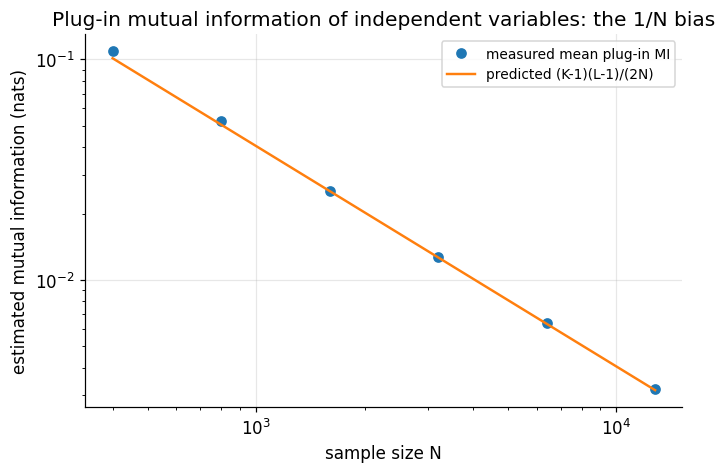

In [7]:
def plugin_mi_nats(xs, ys, kx, ky):
    """Definition 3.7 evaluated on integer-coded samples, in nats."""
    counts = np.zeros((kx, ky))
    np.add.at(counts, (xs, ys), 1.0)
    Q = counts / counts.sum()
    qx, qy = Q.sum(axis=1), Q.sum(axis=0)
    nz = Q > 0.0
    return float((Q[nz] * np.log(Q[nz] / np.outer(qx, qy)[nz])).sum())


kx = ky = 10
sample_sizes = np.array([400, 800, 1600, 3200, 6400, 12800])
trials = 300
measured = np.empty(len(sample_sizes))
for i, N in enumerate(sample_sizes):
    vals = np.empty(trials)
    for t in range(trials):
        vals[t] = plugin_mi_nats(rng.integers(0, kx, N), rng.integers(0, ky, N), kx, ky)
    measured[i] = vals.mean()
predicted = (kx - 1) * (ky - 1) / (2.0 * sample_sizes)
slope = np.polyfit(np.log(sample_sizes), np.log(measured), 1)[0]

print("X and Y independent and uniform on 10 symbols each, so the true I is 0")
print("     N     measured bias   predicted bias   ratio")
for N, m, p in zip(sample_sizes, measured, predicted):
    print(f"  {N:6d}   {m:.6f}        {p:.6f}       {m / p:.4f}")
print(f"  observed order in N = {slope:.4f}   predicted -1")
print(f"  ratio at the largest N = {measured[-1] / predicted[-1]:.4f}")

fig, ax = plt.subplots(figsize=(7.0, 4.4))
ax.loglog(sample_sizes, measured, "o", ms=6, label="measured mean plug-in MI")
ax.loglog(sample_sizes, predicted, lw=1.6, label="predicted (K-1)(L-1)/(2N)")
ax.set_xlabel("sample size N")
ax.set_ylabel("estimated mutual information (nats)")
ax.set_title("Plug-in mutual information of independent variables: the 1/N bias")
ax.legend(fontsize=9)
plt.show()
assert abs(slope + 1.0) < 0.1

The measured order is $-1.0173$ against the predicted $-1$, and the ratio of measured to predicted
bias settles at $1.0075$ by $N = 12800$. The two point sets lie on the same line over five doublings
of $N$.

The practical reading is the number at the left of the plot: at $N = 400$ the estimator reports
$0.108834$ nats, that is $0.157$ bits, for variables with no dependence whatsoever. A positive
$\hat{I}$ means nothing without a null; permuting $Y$ against $X$ reproduces this same bias and is
the only defensible baseline.

### 7.3 Counterexamples: what each hypothesis is holding up

Five checks. The first three drop a hypothesis claimed necessary in Section 4 — joint Gaussianity in
Theorem 4.6, the Markov property in Theorem 4.4, and the tempting but false monotonicity of
conditioning that Theorem 4.2 does **not** assert. The last two break the two modern results: the
sampling hypothesis of Theorem 4.8 and the memorylessness hypothesis of Theorem 4.10.

In [8]:
print("(i) Theorem 4.6 needs joint Gaussianity, not just zero correlation")
P_sq = np.zeros((3, 2))
P_sq[0, 1] = P_sq[1, 0] = P_sq[2, 1] = 1.0 / 3.0
xs3 = np.array([-1.0, 0.0, 1.0])
p3 = np.full(3, 1.0 / 3.0)
cov = float((p3 * xs3 * xs3 ** 2).sum() - (p3 * xs3).sum() * (p3 * xs3 ** 2).sum())
I_sq = mutual_information_bits(P_sq)
print(f"  X uniform on -1, 0, 1 and Y = X^2:  Cov(X, Y) = {cov:.3e}, so rho = 0")
print(f"  Gaussian formula -0.5 log2(1 - rho^2) = {-0.5 * np.log2(1.0):.6f} bits")
print(f"  true I(X;Y) = H_b(1/3)               = {I_sq:.6f} bits")
print(f"  error = {I_sq:.6f} bits, an O(1) failure and not a rounding effect")
assert abs(cov) < 1e-15 and I_sq > 0.9

print("\n(ii) Theorem 4.4 needs the Markov hypothesis")
P_bad = np.zeros((2, 2, 2))
for x in (0, 1):
    for y in (0, 1):
        P_bad[x, y, x] = 0.25
I_xy = mutual_information_bits(P_bad.sum(axis=2))
I_xz = mutual_information_bits(P_bad.sum(axis=1))
I_xz_given_y = conditional_mi_bits(np.transpose(P_bad, (0, 2, 1)))
print("  Y is an independent fair bit and Z = X exactly, so X -> Y -> Z is false")
print(f"  I(X;Y) = {I_xy:.6f}   I(X;Z) = {I_xz:.6f}"
      f"   the conclusion I(X;Y) >= I(X;Z) FAILS by {I_xz - I_xy:.6f} bits")
print(f"  the violated hypothesis: I(X;Z|Y) = {I_xz_given_y:.6f} bits, not 0")
assert I_xz > I_xy and I_xz_given_y > 0.9

print("\n(iii) conditioning is not monotone (Theorem 4.2 never said it was)")
I_xy_xor = mutual_information_bits(P_xor.sum(axis=2))
I_xy_given_z = conditional_mi_bits(P_xor)
print("  X1, X2 independent fair bits and Z = X1 xor X2")
print(f"  I(X1;X2) = {I_xy_xor:.6f}   I(X1;X2|Z) = {I_xy_given_z:.6f}")
print(f"  interaction information I(X1;X2) - I(X1;X2|Z) = {I_xy_xor - I_xy_given_z:+.6f} bits")
assert I_xy_given_z > I_xy_xor

print("\n(iv) Theorem 4.8 needs negatives drawn from p(y), independently of x1")
e_nce = 0.1
I_nce = (1.0 - binary_entropy(np.array(e_nce))) * LOG2


def nce_loss_exact(neg_law):
    """L_NCE at K = 2 for a BSC(e) pair with the optimal critic, by exact enumeration.

    neg_law(x, y) is the probability the negative candidate takes the value y.
    """
    total = 0.0
    for x in (0, 1):
        for y1 in (0, 1):
            p1 = (1.0 - e_nce) if y1 == x else e_nce
            r1 = 2.0 * p1
            for y2 in (0, 1):
                r2 = 2.0 * ((1.0 - e_nce) if y2 == x else e_nce)
                total -= 0.5 * p1 * neg_law(x, y2) * np.log(r1 / (r1 + r2))
    return total


L_ok = nce_loss_exact(lambda x, y: 0.5)
L_bad = nce_loss_exact(lambda x, y: 0.99 if y == 1 - x else 0.01)
print(f"  negatives from the marginal p(y):  L = {L_ok:.6f},"
      f" bound = {np.log(2.0) - L_ok:.6f} nats  <= I = {I_nce:.6f}")
print(f"  negatives steered away from x1  :  L = {L_bad:.6f},"
      f" bound = {np.log(2.0) - L_bad:.6f} nats  >  I = {I_nce:.6f}")
print(f"  the bound is violated by {np.log(2.0) - L_bad - I_nce:.6f} nats")
assert np.log(2.0) - L_ok <= I_nce
assert np.log(2.0) - L_bad > I_nce

print("\n(v) Theorem 4.10 needs a memoryless channel")
P_mem = np.zeros((4, 4))
for x1 in (0, 1):
    for x2 in (0, 1):
        for z in (0, 1):
            w = 0.25 * ((1.0 - e_nce) if z == 0 else e_nce)
            P_mem[2 * x1 + x2, 2 * (x1 ^ z) + (x2 ^ z)] += w
I_two_use = mutual_information_bits(P_mem)
C_single = 1.0 - binary_entropy(np.array(e_nce))
print("  two uses of a BSC(0.1) whose flip bit is the SAME on both uses")
print(f"  I(X^2;Y^2) = {I_two_use:.6f} bits   2C = {2 * C_single:.6f} bits"
      f"   excess {I_two_use - 2 * C_single:.6f} bits")
print("  Lemma 5.9a, and with it the converse, fails for a channel with memory")
assert I_two_use > 2 * C_single

(i) Theorem 4.6 needs joint Gaussianity, not just zero correlation
  X uniform on -1, 0, 1 and Y = X^2:  Cov(X, Y) = 0.000e+00, so rho = 0
  Gaussian formula -0.5 log2(1 - rho^2) = -0.000000 bits
  true I(X;Y) = H_b(1/3)               = 0.918296 bits
  error = 0.918296 bits, an O(1) failure and not a rounding effect

(ii) Theorem 4.4 needs the Markov hypothesis
  Y is an independent fair bit and Z = X exactly, so X -> Y -> Z is false
  I(X;Y) = 0.000000   I(X;Z) = 1.000000   the conclusion I(X;Y) >= I(X;Z) FAILS by 1.000000 bits
  the violated hypothesis: I(X;Z|Y) = 1.000000 bits, not 0

(iii) conditioning is not monotone (Theorem 4.2 never said it was)
  X1, X2 independent fair bits and Z = X1 xor X2
  I(X1;X2) = 0.000000   I(X1;X2|Z) = 1.000000
  interaction information I(X1;X2) - I(X1;X2|Z) = -1.000000 bits

(iv) Theorem 4.8 needs negatives drawn from p(y), independently of x1
  negatives from the marginal p(y):  L = 0.509115, bound = 0.184032 nats  <= I = 0.368064
  negatives steer

Case (i) is the loudest: the Gaussian formula returns $0$ bits for a pair in which $Y$ is a
deterministic function of $X$, and the true value is $0.918296$ bits. Correlation is a second-moment
summary and cannot see a symmetric nonlinearity; Theorem 4.6 is a statement about jointly Gaussian
pairs and nothing else.

Case (ii) violates the data-processing inequality by a full bit, because $Z$ copies $X$ rather than
reading it through $Y$. The diagnostic is the printed $I(X; Z \mid Y) = 1$ bit: Definition 3.4
requires that number to be zero, and Proof 5.4 Step 2 is where it is consumed.

Case (iii) is the negative interaction information promised in Section 2. Observing the parity makes
two independent bits perfectly dependent, so no three-circle area diagram can be drawn for this
triple.

Case (iv) breaks Theorem 4.8. Steering the negative candidate away from $x_1$ makes the
classification task artificially easy, the loss drops to $0.171039$ nats, and the certificate rises
to $0.522108$ nats against a true $I$ of $0.368064$ — a violation of $0.154044$ nats. This is the
practical trap in contrastive pipelines that filter or mine their negatives: the reported number
stops being a lower bound. The proof shows precisely where it breaks, at the exchangeability
argument of Proof 5.8 Step 4.

Case (v) breaks Lemma 5.9a and with it the converse. Two uses of a binary symmetric channel that
share a single flip bit carry $1.531004$ bits, against $2C = 1.062009$ for two independent uses: the
shared noise is itself information the receiver can exploit. Memorylessness is not a convenience
assumption in Theorem 4.10, it is what makes capacity a per-use quantity at all.

### 7.4 Hand-rolled implementations against the library

Three comparisons. The plug-in estimator is checked against `sklearn.metrics.mutual_info_score`; a
from-scratch Kraskov-Stoegbauer-Grassberger estimator is checked against
`sklearn.feature_selection.mutual_info_regression` and against the exact Gaussian value of
Theorem 4.6; and a from-scratch Blahut-Arimoto capacity iteration is checked against the closed
forms of Example 6.4 and against a `scipy` scan.

In [9]:
from scipy.optimize import minimize_scalar
from scipy.spatial import cKDTree
from scipy.special import digamma
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import mutual_info_score

print("(a) discrete plug-in estimator against sklearn.metrics.mutual_info_score")
kx_d, ky_d, N_d = 5, 4, 4000
xs_d = rng.integers(0, kx_d, N_d)
ys_d = (xs_d + rng.integers(0, 2, N_d)) % ky_d
contingency = np.zeros((kx_d, ky_d))
np.add.at(contingency, (xs_d, ys_d), 1.0)
mine = mutual_information_bits(contingency / contingency.sum()) * LOG2
theirs = mutual_info_score(None, None, contingency=contingency)
print(f"  hand-rolled = {mine:.15f} nats")
print(f"  sklearn     = {theirs:.15f} nats")
print(f"  difference  = {abs(mine - theirs):.3e} = {abs(mine - theirs) / EPS:.2f} machine epsilons")
assert abs(mine - theirs) < 1e-12


def ksg_mi_nats(x, y, k=4):
    """Kraskov-Stoegbauer-Grassberger estimator, algorithm 1, in nats."""
    x = np.asarray(x, dtype=float).reshape(-1, 1)
    y = np.asarray(y, dtype=float).reshape(-1, 1)
    n = len(x)
    z = np.hstack([x, y])
    tree_z, tree_x, tree_y = cKDTree(z), cKDTree(x), cKDTree(y)
    radii = tree_z.query(z, k=k + 1, p=np.inf)[0][:, k]
    nx = np.array([len(tree_x.query_ball_point(x[i], radii[i] - 1e-15, p=np.inf)) - 1
                   for i in range(n)])
    ny = np.array([len(tree_y.query_ball_point(y[i], radii[i] - 1e-15, p=np.inf)) - 1
                   for i in range(n)])
    return float(digamma(k) + digamma(n) - np.mean(digamma(nx + 1) + digamma(ny + 1)))


print("\n(b) hand-rolled KSG against sklearn.feature_selection.mutual_info_regression")
rho_g, n_g = 0.8, 2000
chol = np.linalg.cholesky(np.array([[1.0, rho_g], [rho_g, 1.0]]))
gauss = chol @ rng.standard_normal((2, n_g))
I_exact = -0.5 * np.log(1.0 - rho_g ** 2)
I_mine = ksg_mi_nats(gauss[0], gauss[1], k=4)
I_lib = float(mutual_info_regression(gauss[0].reshape(-1, 1), gauss[1],
                                     n_neighbors=4, random_state=0)[0])
print(f"  exact (Theorem 4.6) = {I_exact:.6f} nats")
print(f"  hand-rolled KSG     = {I_mine:.6f} nats   relative error {abs(I_mine - I_exact) / I_exact:.3%}")
print(f"  sklearn             = {I_lib:.6f} nats   relative error {abs(I_lib - I_exact) / I_exact:.3%}")
print(f"  the two implementations differ by {abs(I_mine - I_lib):.2e} nats")
assert abs(I_mine - I_lib) < 0.01


def blahut_arimoto(channel, tol=1e-13, max_iter=5000):
    """Capacity of a discrete memoryless channel, in bits, by alternating maximization."""
    r = np.full(channel.shape[0], 1.0 / channel.shape[0])
    for it in range(max_iter):
        qy = r @ channel
        with np.errstate(divide="ignore", invalid="ignore"):
            ratio = np.where(channel > 0.0,
                             np.log(np.where(channel > 0.0, channel, 1.0))
                             - np.log(np.where(qy > 0.0, qy, 1.0))[None, :], 0.0)
        r_new = r * np.exp((channel * ratio).sum(axis=1))
        r_new /= r_new.sum()
        if np.max(np.abs(r_new - r)) < tol:
            r = r_new
            break
        r = r_new
    return mutual_information_bits(r[:, None] * channel), r, it


print("\n(c) hand-rolled Blahut-Arimoto against closed forms and a scipy scan")
for e_ba in (0.1, 0.2, 0.35):
    C_ba, r_ba, iters = blahut_arimoto(bsc(e_ba))
    closed = 1.0 - binary_entropy(np.array(e_ba))
    print(f"  BSC({e_ba}):   BA = {C_ba:.12f}   1 - H_b(eps) = {closed:.12f}   input {r_ba}")
    assert abs(C_ba - closed) < 1e-12
for e_ba in (0.3, 0.5):
    W_bec = np.array([[1.0 - e_ba, e_ba, 0.0], [0.0, e_ba, 1.0 - e_ba]])
    C_ba, r_ba, iters = blahut_arimoto(W_bec)
    print(f"  BEC({e_ba}):   BA = {C_ba:.12f}   1 - eps      = {1.0 - e_ba:.12f}   input {r_ba}")
    assert abs(C_ba - (1.0 - e_ba)) < 1e-12
W_z = np.array([[1.0, 0.0], [0.25, 0.75]])
C_z, r_z, iters_z = blahut_arimoto(W_z)
scan = minimize_scalar(lambda pi: -I_of_input(pi, W_z),
                       bounds=(1e-9, 1.0 - 1e-9), method="bounded",
                       options={"xatol": 1e-12})
print(f"  Z-channel:   BA = {C_z:.12f}   scipy scan = {-scan.fun:.12f}   ({iters_z} iterations)")
print(f"               BA input {r_z}   scipy input [{1 - scan.x:.7f} {scan.x:.7f}]")
assert abs(C_z - (-scan.fun)) < 1e-9

(a) discrete plug-in estimator against sklearn.metrics.mutual_info_score
  hand-rolled = 0.673343284922009 nats
  sklearn     = 0.673343284922008 nats
  difference  = 3.331e-16 = 1.50 machine epsilons

(b) hand-rolled KSG against sklearn.feature_selection.mutual_info_regression
  exact (Theorem 4.6) = 0.510826 nats
  hand-rolled KSG     = 0.517576 nats   relative error 1.321%
  sklearn             = 0.517936 nats   relative error 1.392%
  the two implementations differ by 3.60e-04 nats

(c) hand-rolled Blahut-Arimoto against closed forms and a scipy scan
  BSC(0.1):   BA = 0.531004406411   1 - H_b(eps) = 0.531004406411   input [0.5 0.5]
  BSC(0.2):   BA = 0.278071905113   1 - H_b(eps) = 0.278071905113   input [0.5 0.5]
  BSC(0.35):   BA = 0.065931944625   1 - H_b(eps) = 0.065931944625   input [0.5 0.5]
  BEC(0.3):   BA = 0.700000000000   1 - eps      = 0.700000000000   input [0.5 0.5]
  BEC(0.5):   BA = 0.500000000000   1 - eps      = 0.500000000000   input [0.5 0.5]
  Z-channel:   BA 

The discrete estimator agrees with `sklearn` to $1.5$ machine epsilons: two independent code paths
landing on the same fifteen digits.

The two KSG implementations differ by $3.6 \times 10^{-4}$ nats — the residue of the tiny jitter
`sklearn` adds to break ties — while both sit about $1.3\%$ *above* the exact
$0.510826$ nats at $n = 2000$. Agreement between implementations is not accuracy: the shared error
is the estimator's own, and only the exact Gaussian value of Theorem 4.6 exposes it.

Blahut-Arimoto reproduces $1 - H_b(\epsilon)$ for the symmetric channel and $1 - \epsilon$ for the
erasure channel to twelve digits, both with a uniform capacity-achieving input. The asymmetric
Z-channel is the interesting one: the optimizer agrees with the `scipy` scan to twelve digits and
the capacity-achieving input is $(0.5722, 0.4278)$, **not** uniform. Theorem 4.5 is what guarantees
the iteration finds the global optimum rather than a local one.

### 7.5 The InfoNCE bound and the $\log K$ ceiling

The last experiment tests Theorem 4.8 on a joint whose mutual information is known exactly: a
$16$-symbol alphabet with a uniform input and a $5\%$ symmetric confusion, giving
$I(X; Y) = 2.438671$ nats. The optimal critic of Proof 5.8 Step 7 is available in closed form here,
so the measured $\log K - \mathcal{L}_{\mathrm{NCE}}$ is the *best* certificate the method can
produce at each $K$.

true I(X;Y) = 2.438671 nats, alphabet size 16, confusion 0.05
    K    L_NCE     log K    log K - L_NCE   below log K   below I
     2   0.0916   0.6931       0.6015         True        True
     4   0.2416   1.3863       1.1447         True        True
     8   0.4671   2.0794       1.6124         True        True
    16   0.7938   2.7726       1.9788         True        True
    32   1.2478   3.4657       2.2179         True        True
    64   1.8329   4.1589       2.3260         True        True
   128   2.4662   4.8520       2.3858         True        True
  constant critic at K = 4: L_NCE = 1.386294, log 4 = 1.386294, certificate = 4.44e-16


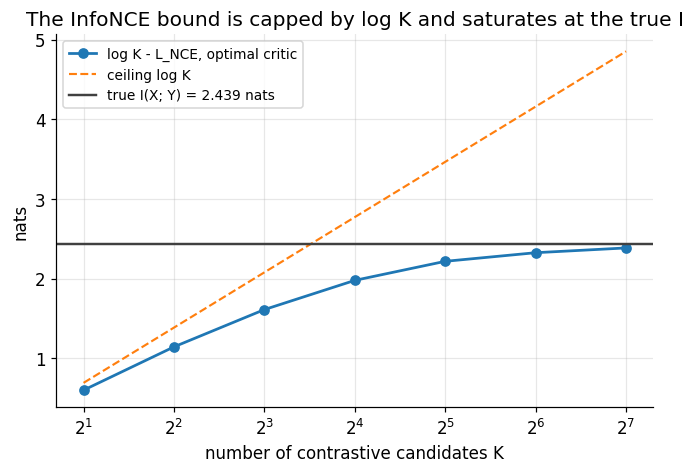

In [10]:
from scipy.special import logsumexp

A_size, flip_p = 16, 0.05
W_nce = np.full((A_size, A_size), flip_p / (A_size - 1))
np.fill_diagonal(W_nce, 1.0 - flip_p)
P_nce = np.full(A_size, 1.0 / A_size)[:, None] * W_nce
I_nce_true = mutual_information_bits(P_nce) * LOG2
cdf = np.cumsum(W_nce, axis=1)
n_mc = 50_000


def infonce_loss(K, optimal=True):
    """Monte-Carlo estimate of Definition 3.6 with the optimal or a constant critic."""
    x = rng.integers(0, A_size, n_mc)
    y_pos = (rng.random(n_mc)[:, None] > cdf[x]).sum(axis=1)
    y_neg = rng.integers(0, A_size, (n_mc, K - 1))
    ys = np.concatenate([y_pos[:, None], y_neg], axis=1)
    f = np.log(A_size * W_nce[x[:, None], ys]) if optimal else np.zeros(ys.shape)
    return float(-np.mean(f[:, 0] - logsumexp(f, axis=1)))


Ks = np.array([2, 4, 8, 16, 32, 64, 128])
losses = np.array([infonce_loss(int(K)) for K in Ks])
bounds = np.log(Ks) - losses
print(f"true I(X;Y) = {I_nce_true:.6f} nats, alphabet size {A_size}, confusion {flip_p}")
print("    K    L_NCE     log K    log K - L_NCE   below log K   below I")
for K, L, b in zip(Ks, losses, bounds):
    print(f"  {K:4d}  {L:7.4f}  {np.log(K):7.4f}    {b:9.4f}        "
          f"{b <= np.log(K) + 1e-9!s:>5}       {b <= I_nce_true + 1e-9!s:>5}")
L_chance = infonce_loss(4, optimal=False)
print(f"  constant critic at K = 4: L_NCE = {L_chance:.6f}, log 4 = {np.log(4.0):.6f},"
      f" certificate = {np.log(4.0) - L_chance:.2e}")
assert np.all(bounds <= I_nce_true + 1e-9)
assert np.all(bounds <= np.log(Ks) + 1e-9)
assert np.all(losses >= 0.0)

fig, ax = plt.subplots(figsize=(7.0, 4.4))
ax.semilogx(Ks, bounds, "o-", base=2, lw=1.8, ms=6, label="log K - L_NCE, optimal critic")
ax.semilogx(Ks, np.log(Ks), "--", base=2, lw=1.4, label="ceiling log K")
ax.axhline(I_nce_true, color="0.25", lw=1.6, label=f"true I(X; Y) = {I_nce_true:.3f} nats")
ax.set_xlabel("number of contrastive candidates K")
ax.set_ylabel("nats")
ax.set_title("The InfoNCE bound is capped by log K and saturates at the true I")
ax.legend(fontsize=9, loc="upper left")
plt.show()

Every row respects both halves of Theorem 4.8. Two regimes are visible.

For $K \le 8$ the certificate hugs the dashed $\log K$ line: the bound is limited by the batch, not
by the data. At $K = 2$ it returns $0.6015$ nats against a ceiling of $0.6931$ and a truth of
$2.4387$ — the estimator sees under a quarter of what is there.

For $K \ge 32$ the ceiling has passed the truth and the curve flattens against the horizontal line:
$2.2179$, $2.3260$, $2.3858$ nats at $K = 32, 64, 128$, converging to $2.4387$ from below exactly as
Proof 5.8 Step 7 predicts.

The constant critic is the control: it scores every candidate equally, so
$\mathcal{L}_{\mathrm{NCE}} = \log K$ to machine precision and the certificate is zero. A
contrastive loss at chance level proves nothing, and correctly proves nothing.

## 8. Applications

Four settings use the results above as their engine. In each, the quantity being computed is a
mutual information for a structural reason rather than by analogy.

### 8.1 Decision trees and feature selection

The **information gain** of splitting a node on a feature $A$ is exactly $I(Y; A) = H(Y) - H(Y \mid A)$,
and the **gain ratio** of C4.5 divides it by $H(A)$ to counteract the pull of high-cardinality
splits, which Theorem 4.1 explains: $I(Y; A) \le H(A)$, so a feature with many values has a large
budget to exploit.

Ranking features by the marginal score $I(X_j; Y)$ is a *filter*, and Example 6.2 is its canonical
failure: both XOR features score zero. The correct criterion is the chain-rule term
$I(X_j; Y \mid S)$ of Theorem 4.3 for the already-selected set $S$, and mRMR's
$I(X_j; Y) - \frac{1}{\lvert S \rvert}\sum_{k \in S} I(X_j; X_k)$ is a cheap surrogate for it.

### 8.2 Representation learning and fairness certificates

Contrastive encoders — CPC, SimCLR, CLIP — maximize the InfoNCE bound of Theorem 4.8 between two
views of the same datum. Proof 5.8 explains three empirical regularities at once: large batches help
because the ceiling is $\log K$; the trained critic converges to a log density ratio, so its logits
are calibrated similarity scores; and the reported number is a floor, never a measurement.

In the opposite direction, Theorem 4.4 turns an information budget at one layer into a guarantee for
every layer after it. If $S$ is a protected attribute and $S \to X \to Z \to \hat{Y}$, then
$I(S; \hat{Y}) \le I(S; Z)$ for **every** downstream head, including ones trained later by someone
else. Combining with Theorem 4.7 converts the budget in bits into a ceiling on any adversary's
accuracy.

### 8.3 Communication and physics

Capacity $C = \max_{p(x)} I(X; Y)$ is the sharp boundary between achievable and impossible rates:
Theorem 4.9 supplies achievability below it and Theorem 4.10 impossibility above it. For a radio
link the noise power is thermal, $N = k_B T B$, so Theorem 4.6 gives the Shannon-Hartley capacity
$C = B \log_2\left( 1 + P / (k_B T B) \right)$ in bits per second.

Elsewhere in physics the same quantity measures correlation between subsystems: in spin models
$I(\sigma_i; \sigma_j)$ decays with separation and its decay length is *half* the correlation
length, because $I$ is quadratic in the correlation function to leading order. Neural coding uses
$I(\text{stimulus}; \text{spike train})$ as the bits a neuron actually transmits, and
efficient-coding theories posit that sensory systems maximize it under a metabolic constraint.

### 8.4 Diagnostics and what mutual information does not say

$I(X; Y) \gt 0$ is symmetric. It carries no direction and no claim about mechanism: a confounder
produces the same positive number as a causal link. Conditional mutual information
$I(X; Y \mid Z)$ is a *test statistic* for conditional independence, not a proof of one, and
Example 6.2 shows that conditioning on the wrong variable manufactures dependence out of nothing.

Information-plane studies measure $I(X; Z_\ell)$ across layers. Theorem 4.4 says the sequence is
non-increasing, so any reported increase is an artefact of the estimator — usually the binning bias
measured in Section 7.2.

The cell below runs the three quantitative applications on explicit numbers: the information gain of
a concrete split, the attacker-accuracy ceiling implied by a representation-level budget, and the
capacity of a thermal-noise-limited radio link.

In [11]:
print("(a) decision-tree split: information gain is I(Y; A)")
P_split = np.array([[0.45, 0.05], [0.15, 0.35]])
H_lab = entropy_bits(P_split.sum(axis=0))
IG = mutual_information_bits(P_split.T)
print("  100 examples, 60 positive; split into two halves of 45/5 and 15/35")
print(f"  parent H(Y) = H_b(0.6) = {H_lab:.6f} bits")
print(f"  H(Y | A) = {H_lab - IG:.6f} bits,  information gain = {IG:.6f} bits")
print(f"  gain ratio = IG / H(A) = {IG / entropy_bits(P_split.sum(axis=1)):.6f}")

print("\n(b) a representation-level information budget, through Theorems 4.4 and 4.7")
for budget in (0.0, 0.05, 0.25):
    H_S_given_Z = 1.0 - budget
    pe = brentq(lambda p: binary_entropy(np.array(p)) - H_S_given_Z, 1e-12, 0.5, xtol=1e-14)
    print(f"  I(S; Z) = {budget:.2f} bits  ->  H(S | Z) = {H_S_given_Z:.2f} bits"
          f"  ->  any head errs at least {pe:.4f}, accuracy at most {1.0 - pe:.4f}")

print("\n(c) capacity of a thermal-noise-limited radio link")
k_B, T_sys, B_hz, P_rx = 1.380649e-23, 290.0, 10.0e6, 1.0e-12
N_pow = k_B * T_sys * B_hz
snr_link = P_rx / N_pow
print(f"  N = kB T B = {N_pow:.4e} W,  SNR = {snr_link:.3f} = {10 * np.log10(snr_link):.2f} dB")
print(f"  C = B log2(1 + SNR) = {B_hz * np.log2(1.0 + snr_link) / 1e6:.3f} Mbit/s")

(a) decision-tree split: information gain is I(Y; A)
  100 examples, 60 positive; split into two halves of 45/5 and 15/35
  parent H(Y) = H_b(0.6) = 0.970951 bits
  H(Y | A) = 0.675143 bits,  information gain = 0.295807 bits
  gain ratio = IG / H(A) = 0.295807

(b) a representation-level information budget, through Theorems 4.4 and 4.7
  I(S; Z) = 0.00 bits  ->  H(S | Z) = 1.00 bits  ->  any head errs at least 0.5000, accuracy at most 0.5000
  I(S; Z) = 0.05 bits  ->  H(S | Z) = 0.95 bits  ->  any head errs at least 0.3691, accuracy at most 0.6309
  I(S; Z) = 0.25 bits  ->  H(S | Z) = 0.75 bits  ->  any head errs at least 0.2145, accuracy at most 0.7855

(c) capacity of a thermal-noise-limited radio link
  N = kB T B = 4.0039e-14 W,  SNR = 24.976 = 13.98 dB
  C = B log2(1 + SNR) = 46.991 Mbit/s


The split of part (a) buys $0.295807$ bits of a possible $0.970951$: a good split, and its gain
ratio equals its gain because the split itself is balanced and $H(A) = 1$ bit.

Part (b) is the fairness certificate in numbers. A budget of exactly zero bits pins any adversary to
chance, $50\%$. A budget of $0.05$ bits still caps them at $63.09\%$, and $0.25$ bits at $78.55\%$ —
the ceiling degrades fast, which is why "we leak only a quarter of a bit" is a weaker promise than
it sounds.

Part (c) is Theorem 4.6 with physical constants: a $10$ MHz link at room temperature receiving a
picowatt runs at $13.98$ dB and carries $46.991$ Mbit/s. No modulation scheme beats that number, by
Theorem 4.10.

## 9. Key Takeaways

- **Mutual information has four faces and they are equal**: bits saved describing $X$, bits saved
  describing $Y$, the overlap $H(X) + H(Y) - H(X, Y)$, and the divergence from the joint law to the
  product of marginals (Theorem 4.1). Section 7.1 confirms the four agree to $1.25$ machine
  epsilons.

- **It is nonnegative, and zero exactly at independence** (Theorem 4.2). The proof needs only the
  tangent-line bound $\ln t \le t - 1$; the equality case needs its strict form.

- **Information is additive only in context**: $I(X_1, X_2; Y) = I(X_1; Y) + I(X_2; Y \mid X_1)$
  (Theorem 4.3). Two XOR features are worth $0$ bits each and $1$ bit together, which is why
  marginal feature ranking fails.

- **Processing cannot create information, and the loss is an identity**:
  $I(X; Y) - I(X; Z) = I(X; Y \mid Z)$ for $X \to Y \to Z$, with equality exactly at sufficiency
  (Theorem 4.4). Drop the Markov hypothesis and Section 7.3 shows the conclusion failing by a full
  bit.

- **Capacity is a concave maximization** because $p(x) \mapsto I(X; Y)$ is concave (Theorem 4.5),
  which is why Blahut-Arimoto converges to the global optimum — verified in Section 7.4 against
  closed forms and a `scipy` scan.

- **The Gaussian case is closed-form and unit-sensitive**: $I = -\tfrac{1}{2}\ln(1-\rho^2)$ nats and
  $C = \tfrac{1}{2}\ln(1 + P/\sigma^2)$ nats, needing *joint* Gaussianity and a *second-moment*
  constraint (Theorem 4.6). An uncorrelated but dependent pair breaks the first formula by
  $0.918296$ bits.

- **Bits cap accuracy**: Fano gives $H(X \mid Y) \le H_b(P_e) + P_e \log(K-1)$ (Theorem 4.7). Solve
  it numerically; the weakened Corollary 4.7a returned a vacuous $P_e \ge 0$ in Example 6.6 where
  the true ceiling was $81.07\%$.

- **A contrastive run certifies at most $\log K$ nats**: $I \ge \log K - \mathcal{L}_{\mathrm{NCE}}$
  with $\mathcal{L}_{\mathrm{NCE}} \ge 0$ for the **unnormalized** loss (Theorem 4.8). Section 7.5
  measures the certificate rising from $0.6015$ to $2.3858$ nats as $K$ goes from $2$ to $128$
  against a truth of $2.4387$.

- **Capacity is a hard ceiling, not a target**: above it the error probability is bounded below by
  $1 - C/R$ no matter how long the block (Theorem 4.10, proved here; achievability cited as
  Theorem 4.9).

- **Estimation is the hard part**: the plug-in estimator of independent variables reports
  $(K-1)(L-1)/(2N)$ nats rather than zero, an exponent Section 7.2 measures as $-1.0173$ against the
  predicted $-1$. Never report an estimated mutual information without a shuffled null.

## 10. References

**Textbooks.**

- Cover, T. M. and Thomas, J. A. *Elements of Information Theory*, 2nd ed. — mutual information and
  its equivalent forms (section 2.4), the chain rule (section 2.5), the data-processing inequality
  and sufficiency (section 2.8), Fano's inequality (section 2.10, Theorem 2.10.1), concavity of $I$
  in the input and convexity in the channel (Theorem 2.7.4), channel capacity and the coding theorem
  (section 7.7, Theorem 7.7.1, pages 199-205), the converse (section 7.9), the Gaussian channel
  (section 9.1).
- MacKay, D. J. C. *Information Theory, Inference, and Learning Algorithms*, chapters 8 to 10 —
  mutual information, noisy channels, and capacity, with the binary symmetric and erasure channels
  worked in full.
- Csiszar, I. and Koerner, J. *Information Theory: Coding Theorems for Discrete Memoryless Systems*,
  2nd ed., chapter 1 — the same material with sharper finite-blocklength statements.
- Polyanskiy, Y. and Wu, Y. *Information Theory: From Coding to Learning*, chapters 2 to 6 —
  variational representations of divergence, including the form used in Lemma 5.8a.

**Papers.**

- Shannon, C. E. "A mathematical theory of communication", *Bell System Technical Journal* **27**
  (1948), 379-423 and 623-656 — mutual information, capacity, and both halves of the coding theorem.
- Arimoto, S. "An algorithm for computing the capacity of arbitrary discrete memoryless channels",
  *IEEE Transactions on Information Theory* **18**(1) (1972), 14-20; Blahut, R. "Computation of
  channel capacity and rate-distortion functions", *IEEE Transactions on Information Theory*
  **18**(4) (1972), 460-473 — the iteration of Section 7.4.
- Paninski, L. "Estimation of entropy and mutual information", *Neural Computation* **15**(6)
  (2003), 1191-1253 — the plug-in bias of Proposition 4.11, section 4.
- Kraskov, A., Stoegbauer, H. and Grassberger, P. "Estimating mutual information",
  *Physical Review E* **69** (2004), 066138 — the $k$-nearest-neighbour estimator of Section 7.4.
- Nguyen, X., Wainwright, M. J. and Jordan, M. I. "Estimating divergence functionals and the
  likelihood ratio by convex risk minimization", *IEEE Transactions on Information Theory* **56**(11)
  (2010), 5847-5861 — the variational bound behind Lemma 5.8a.
- Barber, D. and Agakov, F. "The IM algorithm: a variational approach to information maximization",
  *NeurIPS* (2003) — the decoder-based lower bound.
- Belghazi, M. I. et al. "MINE: mutual information neural estimation", *ICML* (2018) — the
  Donsker-Varadhan estimator and its minibatch pathologies.
- van den Oord, A., Li, Y. and Vinyals, O. "Representation learning with contrastive predictive
  coding", arXiv:1807.03748 (2018), equation (4) — InfoNCE in the unnormalized convention used here.
- Poole, B., Ozair, S., van den Oord, A., Alemi, A. and Tucker, G. "On variational bounds of mutual
  information", *ICML* (2019) — the unified derivation of Theorem 4.8 and the $\log K$ ceiling.
- McAllester, D. and Stratos, K. "Formal limitations on the measurement of mutual information",
  *AISTATS* (2020) — why no $K$-sample lower bound can much exceed $\log K$.
- Peng, H., Long, F. and Ding, C. "Feature selection based on mutual information: criteria of
  max-dependency, max-relevance, and min-redundancy", *IEEE TPAMI* **27**(8) (2005), 1226-1238 —
  mRMR.

**Within this repository.**

- Prerequisites and downstream modules: [the module graph](../../docs/prerequisites.md).
- Symbol conventions, including the InfoNCE normalization ruling used in Definition 3.6:
  [the notation register](../../docs/notation.md).
- Entropy and differential entropy, used throughout:
  [Module 01](../01_self_information_and_entropy/first_principles.ipynb).
- Joint and conditional entropy, the entropy chain rule, and the canonical proof of Fano's
  inequality cited in Theorem 4.7:
  [Module 02](../02_joint_and_conditional_entropy/first_principles.ipynb).
- KL divergence and the $f$-divergence generalization of Lemma 5.2a:
  [Module 04](../04_kl_divergence_and_f_divergences/first_principles.ipynb).
- Practice problems for this module: [exercises.ipynb](exercises.ipynb).